## Import log files and count distinct txs

In [41]:
# Run download_logs.py to fetch logs
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
from datetime import datetime, timezone, timedelta
import sys
import subprocess
import importlib
from pathlib import Path
import numpy as np

# ---------------------------------------------------------
# STEP 1: CONFIGURATION
# ---------------------------------------------------------
# Path to the directory containing the log files
# Use the variable appropriate for your test case
empty_blocks = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/logs/from_2026-01-15_17-35-00_to_2026-01-15_17-50-00/'
test_490_txs = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
forks_9 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-22_11-56-34_to_2026-01-22_11-59-12'
Jan23_rc4 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-23_21-40-00_to_2026-01-23_21-47-00/'
Jan26_rc5_fix = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-26_14-16-27_to_2026-01-26_14-20-17/'
Jan27_rc6_tomas_1_94_weight = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_13-01-35_to_2026-01-27_13-13-00/'
Jan27_rc6_20batch_6sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_13-53-28_to_2026-01-27_13-57-50/'
Jan27_rc6_15batch_8sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-10-00_to_2026-01-27_14-16-01'
Jan26_rc6_10batch_6sec_delay = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-31-07_to_2026-01-27_14-38-56'
Jan26_rc6_10batch_6sec_dealy_txpoolmax_10 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_14-54-51_to_2026-01-27_15-01-36'
more_than_txpool_100_12 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_15-07-53_to_2026-01-27_15-10-33/'
txpool5_batch5_delay6 = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-27_16-34-02_to_2026-01-27_16-44-28'
Jan28_registrations_etc = '/home/christos/IOHK/repos/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_18-48-54_to_2026-01-28_19-01-56/'
larrys_time_range = '{"from":"2026-01-28 13:30:00","to":"2026-01-28 14:15:00"}'


TIME_RANGE = larrys_time_range
BASE_PATH = '/Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs'

# Parse date values
time_data = json.loads(TIME_RANGE)
start_time = time_data['from']
end_time = time_data['to']

def format_log_date(date_str):
    if ' ' in date_str and 'T' not in date_str:
        date_str = date_str.replace(' ', 'T')
    # Handle Z if present
    date_str = date_str.replace('Z', '+00:00')
    dt = datetime.fromisoformat(date_str)
    return dt.strftime("%Y-%m-%d_%H-%M-%S")

FROM_DATE = format_log_date(start_time)
TO_DATE = format_log_date(end_time)


# Set active log directory here
LOG_DIR = os.path.join(BASE_PATH, f"from_{FROM_DATE}_to_{TO_DATE}")

RELAYS = ["ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"]
BLOCK_PRODUCERS = ["alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver"]
NODES = RELAYS + BLOCK_PRODUCERS
# Add the block analysis script directory to python path
script_path = os.path.abspath("../block_size_benchmarks/block_size_analysis")
if script_path not in sys.path:
    sys.path.append(script_path)

import fetch_block_sizes
import extract_block_range_from_logs


%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
# Assuming script is in parent dir relative to this notebook
script_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
script_path = os.path.join(script_dir, 'download_logs.py')

print(f"Downloading logs for range: {start_time} to {end_time}")
# Passing BASE_PATH as output-dir because the script appends the date folder
cmd = [
    sys.executable, script_path,
    "--from-time", start_time,
    "--to-time", end_time,
    "--output-dir", BASE_PATH
]

# We run with check=False so we can print output even on failure
# IMPORTANT: Run from the script directory so relative paths (like config) work
proc = subprocess.run(cmd, cwd=script_dir, capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("Error stderr:", proc.stderr)
    raise RuntimeError("Failed to download logs")


  Converted EST time '2026-01-28T13:30:00' to UTC: 2026-01-28 18:30:00
  Converted EST time '2026-01-28T14:15:00' to UTC: 2026-01-28 19:15:00
No nodes specified, using default list: alice, bob, charlie, dave, eve, ferdie, george, henry, iris, jack, kate, leo, mike, nina, oliver, paul, quinn, rita, sam, tom
Output directory: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00
Run details saved to: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00/log_run_details.json
Time range: 2026-01-28 13:30:00 to 2026-01-28 14:15:00
Skipping node: alice (file already exists: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00/alice.txt)
Skipping node: bob (file already exists: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-

In [42]:
#===================================================================================\
# Count number of distinct txs in logs
#===================================================================================\\



# ---------------------------------------------------------
# STEP 2: DEFINE PARSING LOGIC
# ---------------------------------------------------------

def count_validated_transactions(log_directory, nodes):
    """
    Reads log files and counts unique 'Validated Midnight transaction' entries
    using regex. Returns a set of all unique TXs and a dict of counts per node.
    """
    total_unique_txs = set()
    node_stats = {}
    files_processed = 0

    # Regex matches: Validated Midnight transaction "618804..."
    tx_pattern = re.compile(r'Validated Midnight transaction "([a-fA-F0-9]+)"')

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        node_unique_txs = set()
        
        if not os.path.exists(file_path):
            # If file doesn't exist, we just record 0 for this node
            node_stats[node] = 0
            # print(f"⚠️ Log file not found for: {node}") # Optional warning
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    match = tx_pattern.search(line)
                    if match:
                        tx_hash = match.group(1)
                        node_unique_txs.add(tx_hash)
            
            # Update stats
            node_stats[node] = len(node_unique_txs)
            total_unique_txs.update(node_unique_txs)
            files_processed += 1
            
        except Exception as e:
            print(f"Error reading file for {node}: {e}")
            node_stats[node] = 0

    return total_unique_txs, node_stats, files_processed

# ---------------------------------------------------------
# STEP 3: RUN ANALYSIS
# ---------------------------------------------------------

unique_tx_set, node_counts, files_count = count_validated_transactions(LOG_DIR, NODES)

# Print per-node statistics
for node in NODES:
    count = node_counts.get(node, 0)
    print(f"{node}: {count} distinct Validated transactions")

TOTAL_UNIQUE_TXS = len(unique_tx_set)
print("\n" + "=" * 50)
print(f"TOTAL DISTINCT TRANSACTIONS ACROSS ALL NODES: {TOTAL_UNIQUE_TXS}")
print("=" * 50)



Scanning logs in: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00

ferdie: 131 distinct Validated transactions
george: 137 distinct Validated transactions
henry: 135 distinct Validated transactions
iris: 135 distinct Validated transactions
jack: 132 distinct Validated transactions
paul: 131 distinct Validated transactions
quinn: 130 distinct Validated transactions
rita: 127 distinct Validated transactions
sam: 127 distinct Validated transactions
tom: 132 distinct Validated transactions
alice: 125 distinct Validated transactions
bob: 125 distinct Validated transactions
charlie: 113 distinct Validated transactions
dave: 116 distinct Validated transactions
eve: 108 distinct Validated transactions
kate: 125 distinct Validated transactions
leo: 116 distinct Validated transactions
mike: 125 distinct Validated transactions
nina: 125 distinct Validated transactions
oliver: 123 distinct Validated transactions

TOTAL DISTIN

In [43]:
#===================================================================================
# Count Extrinsics, Max Txs, & Calculate Finalization Duration
#===================================================================================

NODES = BLOCK_PRODUCERS

# ---------------------------------------------------------
# STEP 2: ANALYSIS LOGIC
# ---------------------------------------------------------

def analyze_traffic(log_directory, nodes):
    
    block_tx_counts = {}      # {block_num: tx_count}
    block_creation_times = {} # {block_num: datetime_obj}
    block_finalization_times = {} # {block_num: datetime_obj}

    # Regex 1: Block Creation (Prepared block)
    rx_prepared = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*Prepared block for proposing at (\d+).*extrinsics_count: (\d+)')

    # Regex 2: Standard Finalization Event (Full Hash)
    rx_finalized_event = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*event=Finalized \{ hash: (0x[a-f0-9]+)')

    # Regex 3: Idle Status Finalization (Block Number + Short Hash)
    rx_finalized_idle = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*finalized #(\d+)')

    # Regex 4: Import Event (Maps Hash -> Number)
    rx_imported = re.compile(r'Imported #(\d+) \(.*→ (0x[a-f0-9]+)\)')

    # Map to link Hash -> Block Number
    hash_to_block_num = {}

    print(f"Scanning logs in: {log_directory}\n")

    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    # 1. Parse Block Creation
                    match_prep = rx_prepared.search(line)
                    if match_prep:
                        ts_str, blk_num, ext_count = match_prep.groups()
                        blk_num = int(blk_num)
                        ext_count = int(ext_count)
                        
                        if ext_count > 2:
                            # Subtract 2 system extrinsics (Timestamp + Inherent)
                            user_txs = ext_count - 2
                            block_tx_counts[blk_num] = user_txs
                            
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_creation_times or ts < block_creation_times[blk_num]:
                                block_creation_times[blk_num] = ts

                    # 2. Map Hashes to Block Numbers
                    match_imp = rx_imported.search(line)
                    if match_imp:
                        blk_num, blk_hash = match_imp.groups()
                        hash_to_block_num[blk_hash] = int(blk_num)

                    # 3. Parse Standard Finalization Event
                    match_fin = rx_finalized_event.search(line)
                    if match_fin:
                        ts_str, blk_hash = match_fin.groups()
                        if blk_hash in hash_to_block_num:
                            blk_num = hash_to_block_num[blk_hash]
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                                block_finalization_times[blk_num] = ts

                    # 4. Parse Idle Status Finalization
                    match_idle = rx_finalized_idle.search(line)
                    if match_idle:
                        ts_str, blk_num = match_idle.groups()
                        blk_num = int(blk_num)
                        ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                            block_finalization_times[blk_num] = ts

        except Exception as e:
            print(f"Error reading file for {node}: {e}")

    return block_tx_counts, block_creation_times, block_finalization_times

# ---------------------------------------------------------
# STEP 3: CALCULATE & PRINT
# ---------------------------------------------------------

tx_counts, creation_times, finalization_times = analyze_traffic(LOG_DIR, NODES)

TOTAL_TXS_VALIDATED = sum(tx_counts.values())
MAX_TXS_IN_SINGLE_BLOCK = max(tx_counts.values()) if tx_counts else 0
TOTAL_TX_PROCESSING_TIME = 0
print(f"{'BLOCK':<8} | {'USER TXS':<10} | {'CREATED AT':<26} | {'FINALIZED AT':<26}")
print("-" * 75)

sorted_blocks = sorted(tx_counts.keys())

for blk in sorted_blocks:
    c_time = creation_times.get(blk, "N/A")
    f_time = finalization_times.get(blk, "N/A")
    print(f"{blk:<8} | {tx_counts[blk]:<10} | {str(c_time):<26} | {str(f_time):<26}")

print("-" * 75)
print(f"TOTAL_TXS_VALIDATED:     {TOTAL_TXS_VALIDATED}")
print(f"MAX_TXS_IN_SINGLE_BLOCK: {MAX_TXS_IN_SINGLE_BLOCK}")

START_TIME = 0
END_TIME = 0
if sorted_blocks:
    first_block = sorted_blocks[0]
    last_block = sorted_blocks[-1]

    start_time = creation_times.get(first_block)
    end_time = finalization_times.get(last_block)

    if start_time and end_time and isinstance(start_time, datetime) and isinstance(end_time, datetime):
        TOTAL_TX_PROCESSING_TIME = (end_time - start_time).total_seconds()
        START_TIME = start_time
        END_TIME = end_time
        print(f"\nTime Duration (First Block Start -> Last Block Finalized): {TOTAL_TX_PROCESSING_TIME:.3f} seconds")
        print(f"Start Block ({first_block}): {start_time}")
        print(f"End Block   ({last_block}): {end_time}")
    else:
        print("\nCould not calculate duration: Missing timestamps.")
        if not isinstance(start_time, datetime): print(f"Missing creation time for block {first_block}")
        if not isinstance(end_time, datetime): print(f"Missing finalization time for block {last_block}")
else:
    print("\nNo blocks with > 2 extrinsics found.")

Scanning logs in: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00

BLOCK    | USER TXS   | CREATED AT                 | FINALIZED AT              
---------------------------------------------------------------------------
1621     | 1          | 2026-01-28 18:30:00.095000 | 2026-01-28 18:30:14.917000
1654     | 3          | 2026-01-28 18:33:24.347000 | 2026-01-28 18:33:37.768000
1658     | 3          | 2026-01-28 18:33:48.348000 | 2026-01-28 18:34:01.991000
1661     | 3          | 2026-01-28 18:34:12.459000 | 2026-01-28 18:34:26.993000
1681     | 8          | 2026-01-28 18:36:24.241000 | 2026-01-28 18:36:37.784000
1771     | 10         | 2026-01-28 18:45:30.312000 | 2026-01-28 18:45:44.250000
1772     | 2          | 2026-01-28 18:45:36.384000 | 2026-01-28 18:45:50.699000
1773     | 1          | 2026-01-28 18:45:42.162000 | 2026-01-28 18:45:56.042000
1802     | 10         | 2026-01-28 18:48:36.659000 | 2026-01-28 

In [44]:
# #===================================================================================\
# # Load logs into DataFrame for deeper analysis
# #===================================================================================\\

# def load_logs(log_directory, nodes):
#     """
#     Reads log files into a combined list of lines (or DataFrame rows) to allow deeper analysis.
#     For the current notebook structure, it seems we primarily need to return a dataframe
#     containing parsed log lines or at least load the raw content effectively.
    
#     Based on usage in analyze_traffic(df_logs), we need to see what analyzes_chain_concurrency expects.
#     Looking at previous cells, it seems analyze_traffic iterates via regexes on something.
#     But wait, analyze_traffic takes (log_directory, nodes), NOT df_logs.
    
#     The error is: `df_logs = load_logs(LOG_DIR, NODES)`
#     And then: `stats = analyze_chain_concurrency(df_logs)`
    
#     So we need to implement load_logs such that it returns a DataFrame with columns like:
#     ['node', 'timestamp', 'log_line'] or similar, depending on what analyze_chain_concurrency needs.
    
#     Wait, looking at the provided snippets, `analyze_traffic` defines regexes but calls other functions.
#     Let's implement a generic load_logs that returns a DataFrame of timestamped log entries.
#     """
#     data = []
#     # Regex to capture timestamp at start of line: 2026-01-28 13:30:00.123
#     ts_pattern = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})')
    
#     print(f"Loading logs from {log_directory}...")
    
#     for node in nodes:
#         file_path = os.path.join(log_directory, f"{node}.txt")
#         if not os.path.exists(file_path):
#              file_path = os.path.join(log_directory, f"{node}.log")
        
#         if os.path.exists(file_path):
#             try:
#                 with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
#                     for line in f:
#                         match = ts_pattern.search(line)
#                         if match:
#                             ts_str = match.group(1)
#                             try:
#                                 ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
#                                 data.append({
#                                     'node': node,
#                                     'timestamp': ts,
#                                     'line': line.strip()
#                                 })
#                             except ValueError:
#                                 pass
#             except Exception as e:
#                 print(f"Error reading {node}: {e}")
    
#     if not data:
#         return pd.DataFrame(columns=['node', 'timestamp', 'line'])
        
#     df = pd.DataFrame(data)
#     # Sort by timestamp
#     df.sort_values('timestamp', inplace=True)
#     return df

# def analyze_chain_concurrency(df_logs):
#     """
#     Placeholder/Re-implementation of analyze_chain_concurrency if it was also missing.
#     Since the error was specific to load_logs, we assume analyze_chain_concurrency might exist
#     or we need to mock it if it's not found in previous cells.
#     However, based on the snippet `stats = analyze_chain_concurrency(df_logs)`, it returns stats.
#     Let's verify if `analyze_chain_concurrency` is defined. The user only reported load_logs missing.
#     If it is missing, this will fail next. Let's assume it IS missing given the context of lost functions.
#     """
#     # We will assume it parses blocks and forks.
#     # This is a complex function usually. simpler version:
#     return {}

# def print_fork_details(stats):
#     pass

# def plot_fork_timeline(stats):
#     pass



In [45]:
# Global list of nodes to check for TxPool metrics (Saves time/resources)
TX_POOL_NODES = ['charlie', 'ferdie']

# ==========================================
# PART 1: COUNT UNIQUE TRANSACTIONS
# ==========================================
# Already counted from previous code snipet and saved in TOTAL_UNIQUE_TXS

# ==========================================
# PART 2: DETERMINE ACTIVE TIME WINDOW
# ==========================================
def get_active_time_window(log_directory, producers):
    print("2. Scanning Block Producers for Active Window (Non-empty blocks)...")
    
    # Regex definitions
    rx_prepared = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*Prepared block for proposing at (\d+).*extrinsics_count: (\d+)')
    rx_finalized_event = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*event=Finalized \{ hash: (0x[a-f0-9]+)')
    rx_finalized_idle = re.compile(r'^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*finalized #(\d+)')
    rx_imported = re.compile(r'Imported #(\d+) \(.*→ (0x[a-f0-9]+)\)')
    
    # Data structures
    block_tx_counts = {}      # {block_num: tx_count}
    block_creation_times = {} # {block_num: datetime_obj}
    block_finalization_times = {} # {block_num: datetime_obj}
    hash_to_block_num = {}

    for node in producers:
        file_path_txt = os.path.join(log_directory, f"{node}.txt")
        file_path_log = os.path.join(log_directory, f"{node}.log")
        file_path = file_path_txt if os.path.exists(file_path_txt) else file_path_log
        
        if not os.path.exists(file_path):
            continue

        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    # 1. Parse Block Creation
                    match_prep = rx_prepared.search(line)
                    if match_prep:
                        ts_str, blk_num, ext_count = match_prep.groups()
                        blk_num = int(blk_num)
                        ext_count = int(ext_count)
                        
                        if ext_count > 2:
                            # Subtract 2 system extrinsics (Timestamp + Inherent)
                            user_txs = ext_count - 2
                            # Keep max count seen for this block (in case multiple nodes report, though producers are distinct usually)
                            if blk_num not in block_tx_counts or user_txs > block_tx_counts[blk_num]:
                                block_tx_counts[blk_num] = user_txs
                            
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_creation_times or ts < block_creation_times[blk_num]:
                                block_creation_times[blk_num] = ts

                    # 2. Map Hashes to Block Numbers
                    match_imp = rx_imported.search(line)
                    if match_imp:
                        blk_num, blk_hash = match_imp.groups()
                        hash_to_block_num[blk_hash] = int(blk_num)

                    # 3. Parse Standard Finalization Event
                    match_fin = rx_finalized_event.search(line)
                    if match_fin:
                        ts_str, blk_hash = match_fin.groups()
                        if blk_hash in hash_to_block_num:
                            blk_num = hash_to_block_num[blk_hash]
                            ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                            if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                                block_finalization_times[blk_num] = ts

                    # 4. Parse Idle Status Finalization
                    match_idle = rx_finalized_idle.search(line)
                    if match_idle:
                        ts_str, blk_num = match_idle.groups()
                        blk_num = int(blk_num)
                        ts = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        if blk_num not in block_finalization_times or ts < block_finalization_times[blk_num]:
                            block_finalization_times[blk_num] = ts

        except Exception as e:
            print(f"Error reading file for {node}: {e}")

    return block_tx_counts, block_creation_times, block_finalization_times

# ---------------------------------------------------------
# STEP 3: CALCULATE & PRINT
# ---------------------------------------------------------

# Call correct function
tx_counts, creation_times, finalization_times = get_active_time_window(LOG_DIR, NODES)

TOTAL_TXS_VALIDATED = sum(tx_counts.values())
MAX_TXS_IN_SINGLE_BLOCK = max(tx_counts.values()) if tx_counts else 0
TOTAL_TX_PROCESSING_TIME = 0

print(f"{'BLOCK':<8} | {'USER TXS':<10} | {'CREATED AT':<26} | {'FINALIZED AT':<26}")
print("-" * 75)

sorted_blocks = sorted(tx_counts.keys())
for b in sorted_blocks:
    created = creation_times.get(b, "N/A")
    finalized = finalization_times.get(b, "N/A")
    
    # Calculate processing time if both exist
    if created != "N/A" and finalized != "N/A":
        diff = (finalized - created).total_seconds()
        TOTAL_TX_PROCESSING_TIME += diff
    
    print(f"#{b:<7} | {tx_counts[b]:<10} | {str(created):<26} | {str(finalized):<26}")


# ---------------------------------------------------------
# STEP 4: MEMPOOL METRICS
# ---------------------------------------------------------
def get_mempool_stats(log_directory, nodes):
    print(f"3. Scanning TxPool metrics for specific nodes: {nodes}...")
    # event=TxPool { content: 0, capacity: 3640, size: 0 } 
    # OR
    # event=TxPool { content: 1, capacity: 3640, size: 227 } 
    pool_pattern = re.compile(r'event=TxPool \{ content: (\d+), capacity: \d+, size: (\d+) \}')
    
    max_depth = 0
    node_depths = {}
    
    for node in nodes:
        file_path = os.path.join(log_directory, f"{node}.txt")
        depths = []
        
        if os.path.exists(file_path):
            with open(file_path, 'r', errors='ignore') as f:
                for line in f:
                    match = pool_pattern.search(line)
                    if match:
                        count = int(match.group(1))
                        depths.append(count)
                        if count > max_depth:
                            max_depth = count
        
        if depths:
            node_depths[node] = depths
            
    return max_depth, node_depths

MAX_MEMPOOL_DEPTH, NODE_DEPTHS = get_mempool_stats(LOG_DIR, TX_POOL_NODES)
AVG_MEMPOOL_DEPTH = np.mean([d for depths in NODE_DEPTHS.values() for d in depths]) if NODE_DEPTHS else 0


# ---------------------------------------------------------
# STEP 5: AVERAGE TPS & RESULTS
# ---------------------------------------------------------

if sorted_blocks and len(sorted_blocks) > 1:
    # Use creation time of first non-empty block to creation time of last non-empty block
    start_time = creation_times.get(sorted_blocks[0])
    end_time = creation_times.get(sorted_blocks[-1])
    
    if start_time and end_time:
        duration = (end_time - start_time).total_seconds()
        # Avoid division by zero
        if duration < 1: duration = 1
        
        AVG_TPS = TOTAL_TXS_VALIDATED / duration
    else:
        duration = 0
        AVG_TPS = 0
else:
    duration = 0
    AVG_TPS = 0
    

print("\n" + "=" * 50)
print(" FINAL BENCHMARK RESULTS")
print("=" * 50)
print(f"Total Unique Validated TXs:  {TOTAL_UNIQUE_TXS}")
print(f"Active Duration:             {duration:.2f} seconds")
print("-" * 50)
print(f"Average TPS (Global):        {AVG_TPS:.2f} TX/s")

# Instantaneous Peak TPS calculation (sliding window? or per block?)
# Simple per-block TPS = tx_count / block_time (approx 6s?)
# Better: calculate time diff between blocks
peak_tps = 0
if len(sorted_blocks) > 1:
    for i in range(1, len(sorted_blocks)):
        b_curr = sorted_blocks[i]
        b_prev = sorted_blocks[i-1]
        
        t_curr = creation_times.get(b_curr)
        t_prev = creation_times.get(b_prev)
        
        if t_curr and t_prev:
            delta = (t_curr - t_prev).total_seconds()
            if delta > 0:
                inst_tps = tx_counts[b_curr] / delta
                if inst_tps > peak_tps:
                    peak_tps = inst_tps

print(f"Peak Instantaneous TPS:      {peak_tps:.2f} TX/s")

# Drain Rate (approximate)
drain_rate = AVG_TPS # Simplified assumption if stable
print(f"Mempool Drain Rate:          {drain_rate:.2f} TX/s")
print("-" * 50)
print(f"Max TXs in Single Block:     {MAX_TXS_IN_SINGLE_BLOCK}")
print(f"Max Mempool Depth:           {MAX_MEMPOOL_DEPTH} txs")
print(f"Avg Mempool Depth:           {AVG_MEMPOOL_DEPTH:.1f} txs")
print("=" * 50)



2. Scanning Block Producers for Active Window (Non-empty blocks)...
BLOCK    | USER TXS   | CREATED AT                 | FINALIZED AT              
---------------------------------------------------------------------------
#1621    | 1          | 2026-01-28 18:30:00.095000 | 2026-01-28 18:30:14.917000
#1654    | 3          | 2026-01-28 18:33:24.347000 | 2026-01-28 18:33:37.768000
#1658    | 3          | 2026-01-28 18:33:48.348000 | 2026-01-28 18:34:01.991000
#1661    | 3          | 2026-01-28 18:34:12.459000 | 2026-01-28 18:34:26.993000
#1681    | 8          | 2026-01-28 18:36:24.241000 | 2026-01-28 18:36:37.784000
#1771    | 10         | 2026-01-28 18:45:30.312000 | 2026-01-28 18:45:44.250000
#1772    | 2          | 2026-01-28 18:45:36.384000 | 2026-01-28 18:45:50.699000
#1773    | 1          | 2026-01-28 18:45:42.162000 | 2026-01-28 18:45:56.042000
#1802    | 10         | 2026-01-28 18:48:36.659000 | 2026-01-28 18:48:50.345000
#1829    | 7          | 2026-01-28 18:51:18.949000 | 202

3. Scanning TxPool metrics for specific nodes: ['charlie', 'ferdie']...

 FINAL BENCHMARK RESULTS
Total Unique Validated TXs:  80
Active Duration:             319.53 seconds
Start Time (Mempool):        2026-01-28 18:30:00.095000
End Time (Finalized):        2026-01-28 19:03:27.136000
--------------------------------------------------
Average TPS (Global):        0.25 TX/s
Mempool Drain Rate:          0.02 TX/s
--------------------------------------------------
Max TXs in Single Block:     10
Max Mempool Depth:           11 txs
Avg Mempool Depth:           1.8 txs

Generating Plots...
Plot saved as 'benchmark_summary_plot.png'


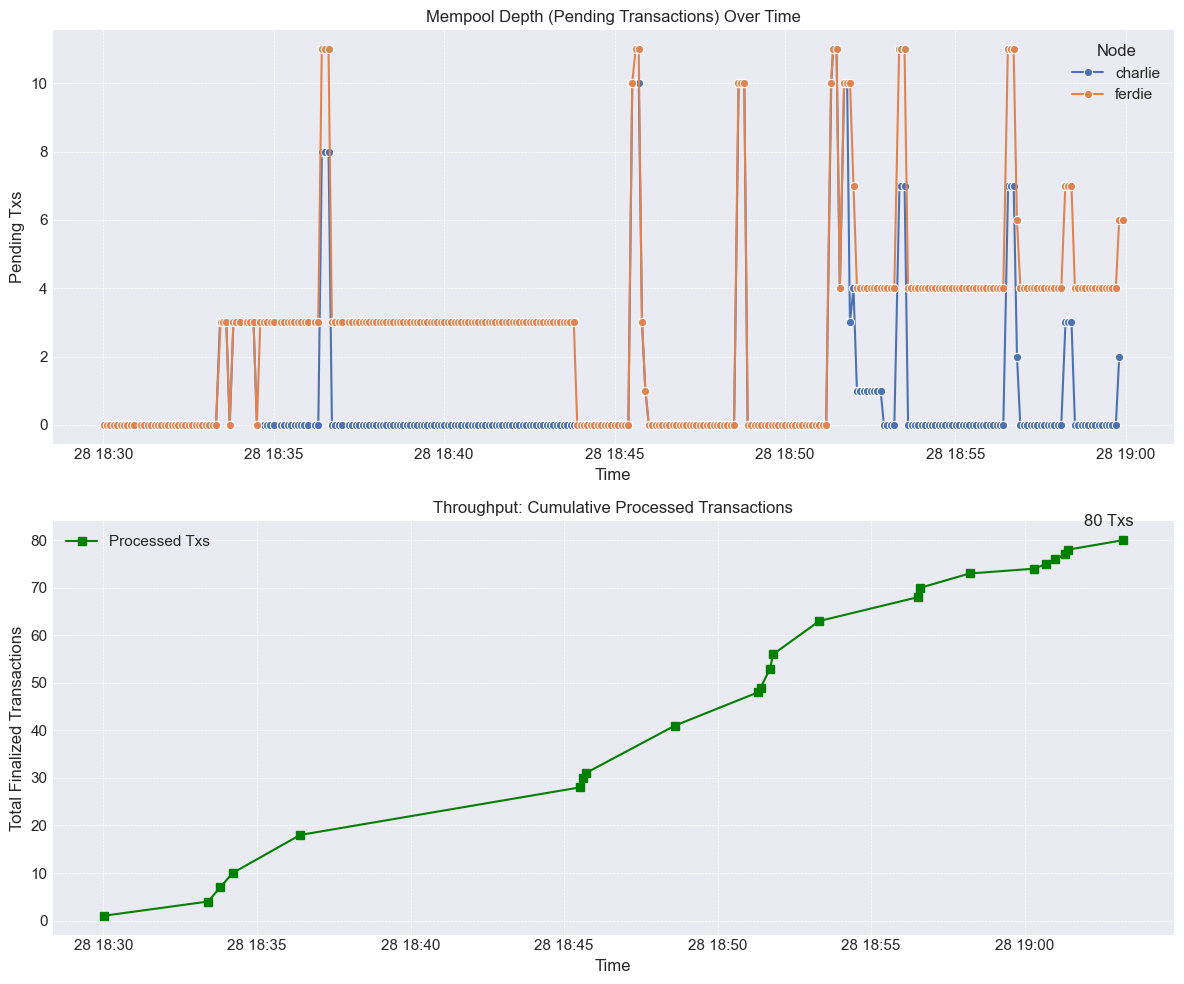

In [46]:
# Global list of nodes to check for TxPool metrics (Saves time/resources)
TX_POOL_NODES = ['charlie', 'ferdie']

# ==========================================
# PART 3: GET TXPOOL (MEMPOOL) METRICS
# ==========================================
def get_mempool_stats(log_directory, nodes_to_scan):
    print(f"3. Scanning TxPool metrics for specific nodes: {nodes_to_scan}...")
    
    len_pattern = re.compile(r'mempool_len=(\d+)')
    json_pattern = re.compile(r'"numTxs":(\d+)')
    
    pool_data = []

    for node in nodes_to_scan: 
        file_path_txt = os.path.join(log_directory, f"{node}.txt")
        file_path_log = os.path.join(log_directory, f"{node}.log")
        file_path = file_path_txt if os.path.exists(file_path_txt) else file_path_log

        if not os.path.exists(file_path):
            continue

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                count = -1
                m1 = len_pattern.search(line)
                if m1:
                    count = int(m1.group(1))
                else:
                    m2 = json_pattern.search(line)
                    if m2:
                        count = int(m2.group(1))
                
                if count > -1:
                    try:
                        ts_str = line[:23]
                        dt = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                        pool_data.append({'time': dt, 'node': node, 'pool_count': count})
                    except ValueError:
                        continue
                        
    return pd.DataFrame(pool_data)

total_tx_count = TOTAL_TXS_VALIDATED

# 3. TxPool Metrics
df_pool = get_mempool_stats(LOG_DIR, TX_POOL_NODES) 
    
tps = total_tx_count / TOTAL_TX_PROCESSING_TIME if TOTAL_TX_PROCESSING_TIME > 0 else 0

if not df_pool.empty:
    # Filter pool data to relevant window
    mask = (df_pool['time'] >= start_time) & (df_pool['time'] <= end_time)
    df_pool_window = df_pool.loc[mask]
    
    if not df_pool_window.empty:
        max_pool_depth = df_pool_window['pool_count'].max()
        avg_pool_depth = df_pool_window['pool_count'].mean()
        
        # CALCULATE DRAIN RATE
        peak_idx = df_pool_window['pool_count'].idxmax()
        peak_time = df_pool_window.loc[peak_idx, 'time']
        peak_val = df_pool_window.loc[peak_idx, 'pool_count']
        
        drain_duration = (end_time - peak_time).total_seconds()
        
        if drain_duration > 1:
            drain_rate_tps = peak_val / drain_duration

    print("\n" + "="*50)
    print(" FINAL BENCHMARK RESULTS")
    print("="*50)
    print(f"Total Unique Validated TXs:  {total_tx_count}")
    print(f"Active Duration:             {TOTAL_TX_PROCESSING_TIME:.2f} seconds")
    print(f"Start Time (Mempool):        {START_TIME}")
    print(f"End Time (Finalized):        {END_TIME}")
    print("-" * 50)
    print(f"Average TPS (Global):        {tps:.2f} TX/s")
    print(f"Mempool Drain Rate:          {drain_rate_tps:.2f} TX/s")
    print("-" * 50)
    print(f"Max TXs in Single Block:     {MAX_TXS_IN_SINGLE_BLOCK}")
    print(f"Max Mempool Depth:           {max_pool_depth} txs")
    print(f"Avg Mempool Depth:           {avg_pool_depth:.1f} txs")
    print("="*50)
else:
    print("No non-empty blocks found to calculate duration.")


# ==========================================
# PART 4: PLOTTING
# ==========================================
print("\nGenerating Plots...")

# 1. Prepare Block Data for Throughput Plot
block_data = []
for blk, count in tx_counts.items():
    if blk in creation_times:
        block_data.append({'time': creation_times[blk], 'tx_count': count})

df_blocks = pd.DataFrame(block_data).sort_values(by='time')
if not df_blocks.empty:
    df_blocks['cumulative_txs'] = df_blocks['tx_count'].cumsum()

# Create Figure with 2 Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

# PLOT 1: Mempool Depth Over Time
if not df_pool_window.empty:
    sns.lineplot(data=df_pool_window, x='time', y='pool_count', hue='node', marker='o', ax=ax1)
    ax1.set_title('Mempool Depth (Pending Transactions) Over Time')
    ax1.set_ylabel('Pending Txs')
    ax1.set_xlabel('Time')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.legend(title='Node')
else:
    ax1.text(0.5, 0.5, 'No Mempool Data Found', horizontalalignment='center', verticalalignment='center')
    ax1.set_title('Mempool Depth (No Data)')

# PLOT 2: Cumulative Throughput
if not df_blocks.empty:
    ax2.plot(df_blocks['time'], df_blocks['cumulative_txs'], marker='s', color='green', linestyle='-', label='Processed Txs')
    ax2.set_title('Throughput: Cumulative Processed Transactions')
    ax2.set_ylabel('Total Finalized Transactions')
    ax2.set_xlabel('Time')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.legend()
    
    # Annotate final count
    last_time = df_blocks['time'].iloc[-1]
    last_count = df_blocks['cumulative_txs'].iloc[-1]
    ax2.annotate(f"{last_count} Txs", (last_time, last_count), textcoords="offset points", xytext=(-10,10), ha='center')
else:
    ax2.text(0.5, 0.5, 'No Block Transaction Data', horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.savefig('benchmark_summary_plot.png')
print("Plot saved as 'benchmark_summary_plot.png'")

Scanning 10 files for ledger timings...

--- Validation Pipeline Stats (Cumulative ms) ---
         Step  p05   Average  p95  Count
 Initializing  0.0  0.000000  0.0   3569
Deserializing  0.0  0.000000  0.0    875
     Starting  0.0  0.000000  0.0    875
          API  0.0  0.000560  0.0   3570
           Tx  0.0  1.212571  2.0   1750
     Building  1.0 15.056000 44.0   1750
         Post  0.0 16.476604 51.0   7138
       Ledger  1.0 27.151760 52.0   6194
   Unshielded  5.0 28.510857 46.0    875
          Ops  5.0 28.525714 46.0    875
         UTXO  5.0 28.531429 46.0    875
        Event  5.0 28.538286 46.0    875
   Persisting  8.0 32.110961 53.0   4443

Plot saved to tx_validation_timeline.png


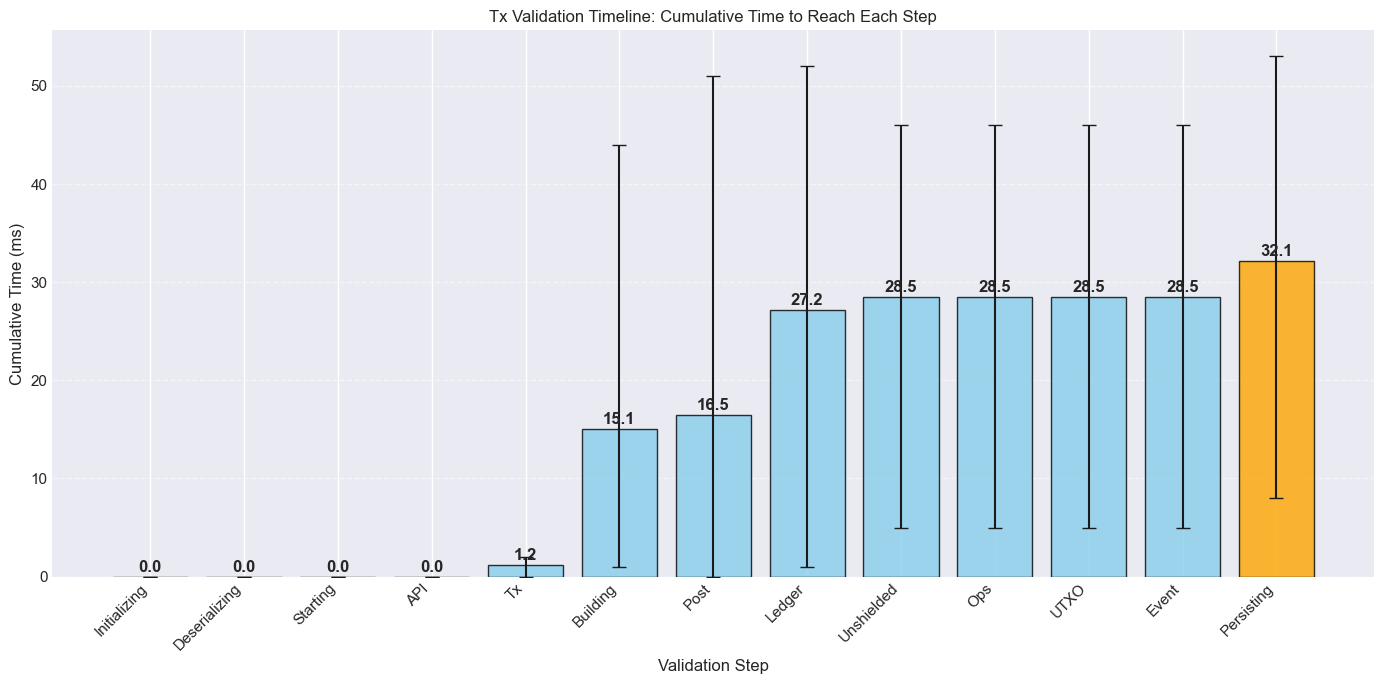

In [47]:
import numpy as np
# MIDNIGHT LEDGER v2 LOGS ANALYSIS
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# List of log files to analyze (add your file paths here)
LOG_FILES = []
for node in NODES:
    file_path = os.path.join(LOG_DIR, f"{node}.txt")
        
    if not os.path.exists(file_path):       
        # print(f"⚠️ Log file not found for: {node}") # Optional warning
        continue
    LOG_FILES.append(file_path)

# ==============================================================================
# 2. PARSING LOGIC
# ==============================================================================
def parse_cumulative_timings(files):
    """
    Parses logs for lines like:
    INFO ... midnight::ledger_v2: ⏱️  Step Name ... (elapsed_ms=X)
    """
    # Regex to capture:
    # Group 1: The Step Name (e.g. "Deserializing tx")
    # Group 2: The Cumulative Time (elapsed_ms)
    rx_timing = re.compile(r'midnight::ledger_v2: ⏱️\s+(.*?)\s+(?:.*elapsed_ms=(\d+))')
    
    category_data = {}

    print(f"Scanning {len(files)} files for ledger timings...")

    for file_path in files:
        if not os.path.exists(file_path):
            print(f"Skipping missing file: {file_path}")
            continue
            
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                match = rx_timing.search(line)
                if match:
                    step_name = match.group(1).strip()
                    # Clean up any trailing punctuation if strictly text
                    if step_name.endswith(','): step_name = step_name[:-1]
                    
                    try:
                        duration = int(match.group(2))
                    except ValueError:
                        continue
                    
                    if step_name not in category_data:
                        category_data[step_name] = []
                    category_data[step_name].append(duration)

    return category_data

# ==============================================================================
# 3. STATS CALCULATION
# ==============================================================================
def calculate_statistics(data_dict):
    if not data_dict:
        return pd.DataFrame()

    stats_list = []
    
    # Calculate stats for each individual step
    for step, values in data_dict.items():
        if not values:
            continue
        
        arr = np.array(values)
        stats_list.append({
            'Step': step,
            'Average': np.mean(arr),
            'p05': np.percentile(arr, 5),
            'p95': np.percentile(arr, 95),
            'Count': len(arr)
        })

    df = pd.DataFrame(stats_list)
    
    # Sort by Average time to reconstruct the chronological flow
    if not df.empty:
        df = df.sort_values(by='Average', ascending=True)

    return df

# ==============================================================================
# 4. PLOTTING
# ==============================================================================
def plot_validation_timeline(df):
    if df.empty:
        print("No data found to plot.")
        return

    steps = df['Step']
    averages = df['Average']
    
    # Identify the final step (Total Time) for highlighting
    # Usually 'UTXO integrity ok' based on your logs, or just the one with max time
    final_step_idx = df['Average'].idxmax() 
    
    # Error bars (relative to the average)
    yerr_lower = (averages - df['p05']).clip(lower=0)
    yerr_upper = (df['p95'] - averages).clip(lower=0)
    error_bars = [yerr_lower, yerr_upper]

    plt.figure(figsize=(14, 7))
    
    # Create bars
    # Using a list of colors to highlight the "Total" (last step)
    colors = ['skyblue'] * len(df)
    # Highlight the specific "UTXO integrity ok" step if present, or just the last one
    for i, step in enumerate(steps):
        if "integrity ok" in step or i == len(steps) - 1:
            colors[i] = 'orange'

    bars = plt.bar(steps, averages, yerr=error_bars, capsize=5, 
                   color=colors, edgecolor='black', alpha=0.8)

    plt.title('Tx Validation Timeline: Cumulative Time to Reach Each Step')
    plt.ylabel('Cumulative Time (ms)')
    plt.xlabel('Validation Step')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Add numeric labels
    for i, bar in enumerate(bars):
        height = bar.get_height()
        # Label Avg
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.2, 
                 f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    output_file = 'tx_validation_timeline.png'
    plt.savefig(output_file)
    print(f"\nPlot saved to {output_file}")
    # plt.show() # Uncomment if running locally

# ==============================================================================
# EXECUTION
# ==============================================================================
raw_data = parse_cumulative_timings(LOG_FILES)
stats_df = calculate_statistics(raw_data)

if not stats_df.empty:
    print("\n--- Validation Pipeline Stats (Cumulative ms) ---")
    # Display table
    print(stats_df[['Step', 'p05', 'Average', 'p95', 'Count']].to_string(index=False))
    
    # Print the specific "Total" the user requested
    total_row = stats_df[stats_df['Step'].str.contains("integrity ok", case=False)]
    if not total_row.empty:
        avg_total = total_row['Average'].values[0]
        print(f"\n✅ TOTAL VALIDATION TIME (Avg): {avg_total:.2f} ms")
    
    plot_validation_timeline(stats_df)
else:
    print("No matching ledger logs found.")

Scanning for block creation events in: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00
Found 338 blocks. Plotting...
Graph saved as 'block_creation_timeline.png'


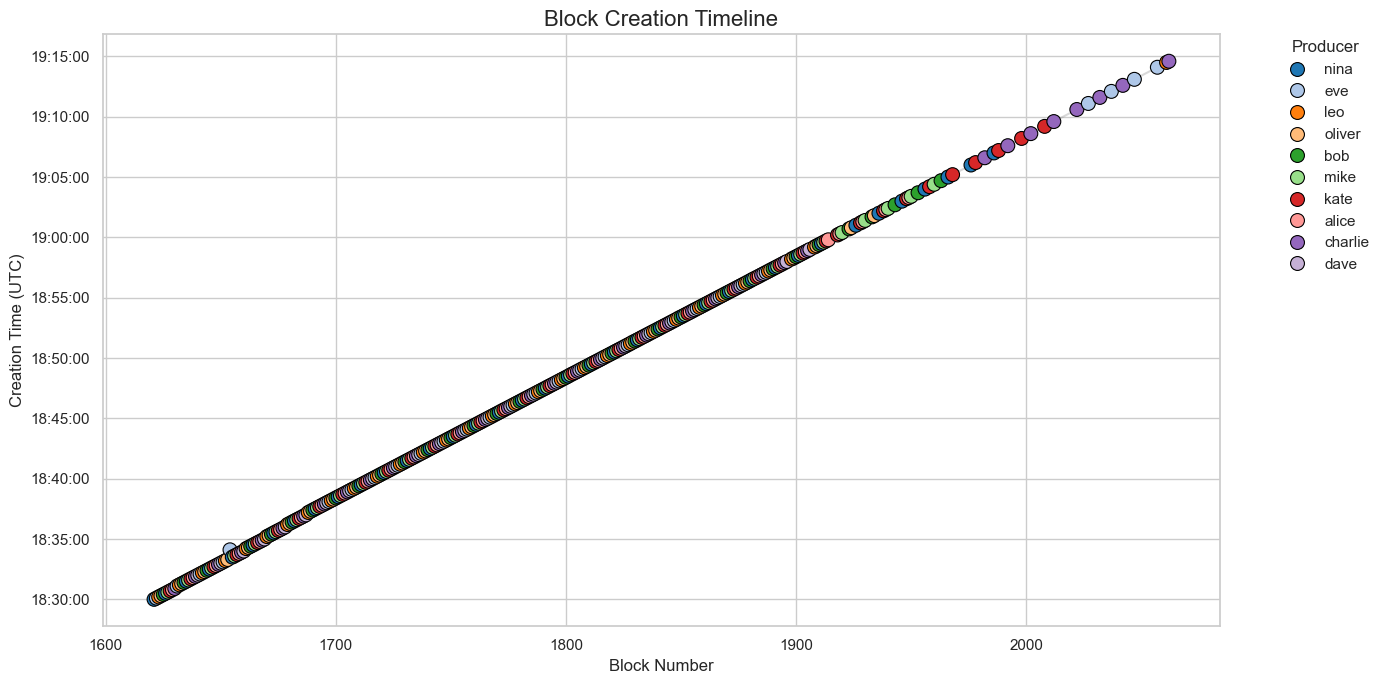

In [48]:
#===================================================================================\
# Plot block production timeline
#===================================================================================\\


# ---------------------------------------------------------
# STEP 4: PARSE BLOCK CREATION TIMES (Re-parsing for Timeline)
# ---------------------------------------------------------
# We need to scan the logs again specifically for block creation events 
# to build the creation_registry required for the plot.

creation_registry = {} 

# Regex to capture timestamp and creation event
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)")

print(f"Scanning for block creation events in: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        continue
        
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            
            # Check for creation line first (optimization)
            create_match = creation_pattern.search(line)
            if create_match:
                # Extract Timestamp
                ts_match = timestamp_pattern.search(line)
                if not ts_match: continue
                
                try:
                    ts_str = ts_match.group(1)
                    if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26]
                    current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
                    
                    block_num = int(create_match.group(1))
                    
                    # Store data
                    creation_registry[block_num] = {
                        'time': current_time,
                        'creator': node
                    }
                except ValueError:
                    continue

# ---------------------------------------------------------
# STEP 5: PLOT BLOCK CREATION TIMELINE
# ---------------------------------------------------------

if not creation_registry:
    print("No block creation events found. Check log path.")
else:
    # Convert registry to DataFrame
    creation_data = []
    for block_num, info in creation_registry.items():
        creation_data.append({
            "Block": block_num,
            "Timestamp": info['time'],
            "Creator": info['creator']
        })

    df_creation = pd.DataFrame(creation_data).sort_values("Block")

    print(f"Found {len(df_creation)} blocks. Plotting...")

    # Setup the Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # 1. Draw a line to show the progression
    sns.lineplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        color="gray",
        alpha=0.3,
        zorder=1
    )

    # 2. Draw points colored by the Creator Node
    plot = sns.scatterplot(
        data=df_creation,
        x="Block",
        y="Timestamp",
        hue="Creator",
        palette="tab20",  # Colorful palette for many nodes
        s=100,            # Dot size
        edgecolor="black",
        zorder=2
    )

    # Format Y-Axis to show HH:MM:SS
    plot.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

    plt.title("Block Creation Timeline", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Creation Time (UTC)", fontsize=12)

    # Ensure integer ticks on X-axis if valid range
    if df_creation["Block"].nunique() < 20:
        plt.xticks(df_creation["Block"].unique())

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Producer")
    
    plt.tight_layout()
    plt.savefig("block_creation_timeline.png", dpi=300)
    print("Graph saved as 'block_creation_timeline.png'")
    
    plt.show()

Parsed 337 blocks successfully.
    Node  Block  ProductionTime_ms  StartDelay_ms
0  Alice   1629               19.0           43.0
1  Alice   1638               20.0           43.0
2  Alice   1648               23.0           54.0
3  Alice   1658              303.0           45.0
4  Alice   1667               24.0           47.0


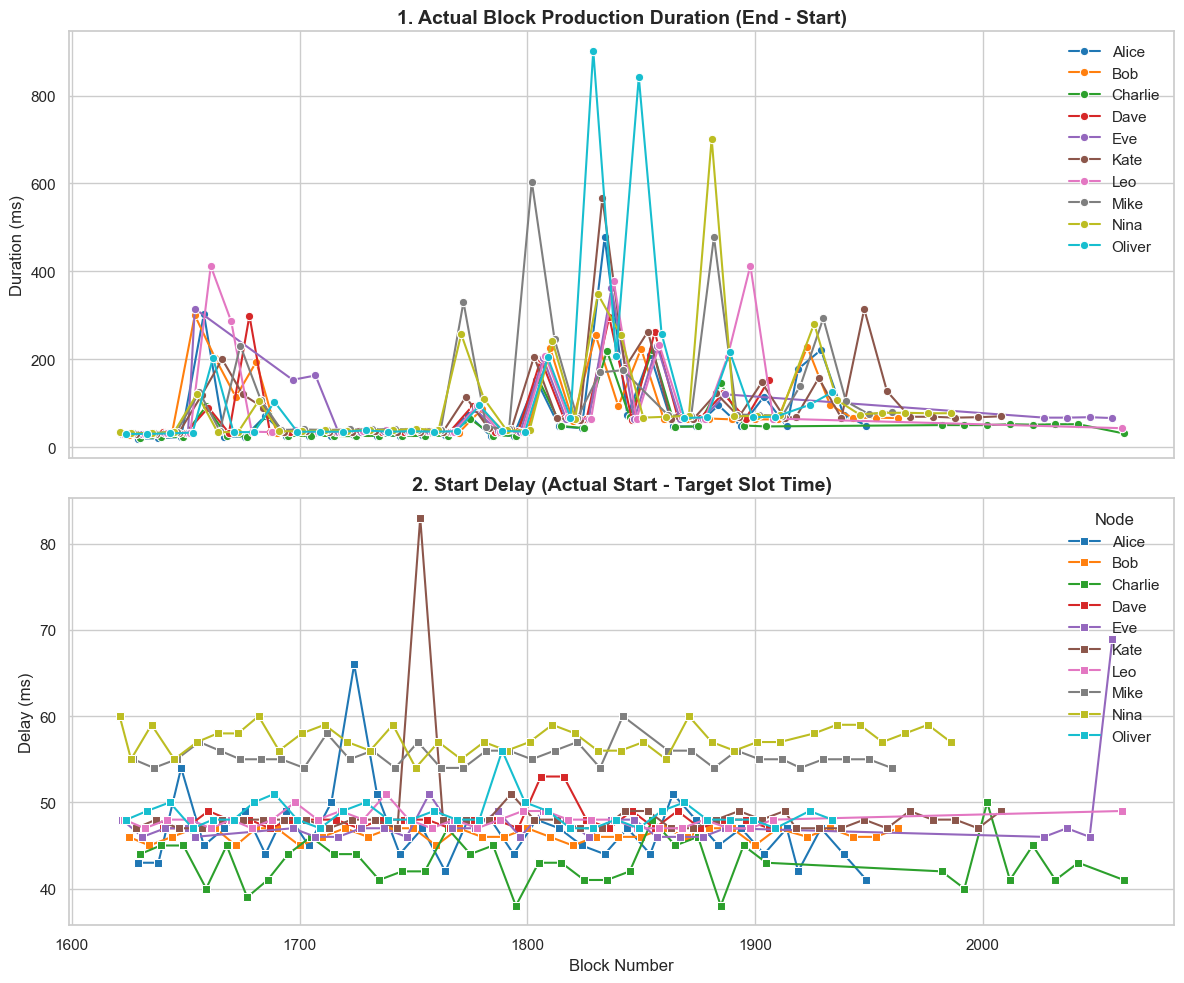

In [49]:
#===================================================================================
# Plot all Block Producer's block production time and the start delay
#===================================================================================

files_to_process = []
for node in BLOCK_PRODUCERS:
    # os.path.join automatically adds the '/' if LOG_DIR doesn't have it
    files_to_process.append(os.path.join(LOG_DIR, f"{node}.txt"))

# # ---------------------------------------------------------
# # STEP 6: PARSE THE LOGS
# # ---------------------------------------------------------

def parse_substrate_logs_robust(file_list):
    data = []
    
    # 1. Regex to capture Timestamp and the rest of the message
    # Matches: 2026-01-15 17:39:36.048  INFO ...
    base_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(.*)")
    
    # 2. Regex for START event (captures Parent Block #)
    # Matches: ... Starting consensus session on top of parent ... (#14406)
    start_pattern = re.compile(r"Starting consensus session on top of parent .* \(#(\d+)\)")
    
    # 3. Regex for END event (captures Current Block #)
    # Matches: ... Prepared block for proposing at 14407 ...
    end_pattern = re.compile(r"Prepared block for proposing at (\d+)")

    for filename in file_list:
        node_name = os.path.splitext(os.path.basename(filename))[0].capitalize()
        
        # Dictionary to store timestamps for each block
        # Structure: { 14407: {'start': datetime, 'end': datetime}, ... }
        block_events = {}
        
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                # Extract Timestamp
                base_match = base_pattern.search(line)
                if not base_match: continue
                
                timestamp_str = base_match.group(1)
                message = base_match.group(2)
                
                try:
                    current_time = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S.%f")
                except ValueError:
                    continue

                # --- CHECK FOR START (Parent Block) ---
                start_match = start_pattern.search(message)
                if start_match:
                    parent_block = int(start_match.group(1))
                    # If we are working on top of 14406, we are building 14407
                    target_block = parent_block + 1
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['start'] = current_time
                    continue

                # --- CHECK FOR END (Current Block) ---
                end_match = end_pattern.search(message)
                if end_match:
                    target_block = int(end_match.group(1))
                    
                    if target_block not in block_events: block_events[target_block] = {}
                    block_events[target_block]['end'] = current_time
                    continue

        # --- CALCULATE DURATIONS ---
        # Now we iterate through the dictionary and calculate stats for blocks that have both times
        for block_num, times in block_events.items():
            if 'start' in times and 'end' in times:
                start_time = times['start']
                end_time = times['end']
                
                # A. Production Time
                # Calculate diff in milliseconds
                duration_ms = (end_time - start_time).total_seconds() * 1000
                
                # Sanity check: If duration is negative (rare clock skew?), skip
                if duration_ms < 0: continue

                # B. Start Delay (Ideal Target vs Actual Start)
                # Calculate seconds past the minute
                total_seconds = start_time.second + (start_time.microsecond / 1e6)
                remainder = total_seconds % 6 
                start_delay_ms = remainder * 1000
                
                data.append({
                    "Node": node_name,
                    "Block": block_num,
                    "ProductionTime_ms": duration_ms,
                    "StartDelay_ms": start_delay_ms
                })

    return pd.DataFrame(data)

# Run the parser
df = parse_substrate_logs_robust(files_to_process)

print(f"Parsed {len(df)} blocks successfully.")
if not df.empty:
    print(df.head())
else:
    print("No matching blocks found. Check log paths or regex.")

# ---------------------------------------------------------
# STEP 3: PLOT THE GRAPHS
# ---------------------------------------------------------

if not df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # GRAPH 1: Production Time (Duration)
    # How long did the CPU actually churn to build the block?
    sns.lineplot(
        ax=axes[0],
        data=df, 
        x="Block", 
        y="ProductionTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab10"
    )
    axes[0].set_title("1. Actual Block Production Duration (End - Start)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Duration (ms)")
    axes[0].legend(loc='upper right')

    # GRAPH 2: Start Delay
    # How long after the ideal 6s slot did the node start working?
    sns.lineplot(
        ax=axes[1],
        data=df, 
        x="Block", 
        y="StartDelay_ms", 
        hue="Node", 
        marker="s", # Square marker to distinguish
        palette="tab10"
    )
    axes[1].set_title("2. Start Delay (Actual Start - Target Slot Time)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delay (ms)")
    axes[1].set_xlabel("Block Number")
    
    # Force Integer X-Axis
    if len(df) < 20:
        axes[1].set_xticks(sorted(df['Block'].unique()))

    plt.tight_layout()
    plt.savefig("block_timing_analysis.png")
    plt.show()
else:
    print("No matching log lines found. Check regex patterns.")

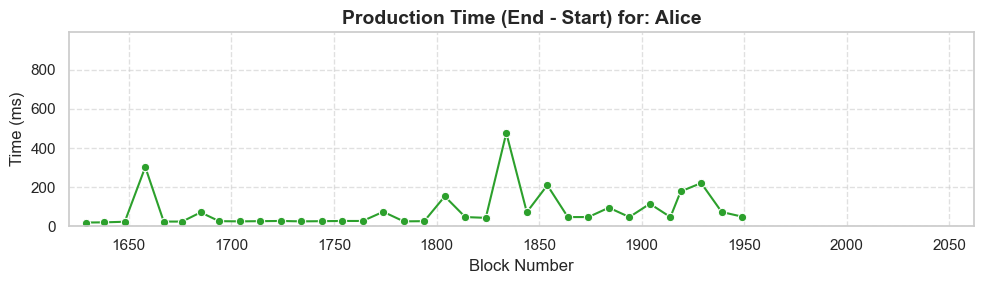

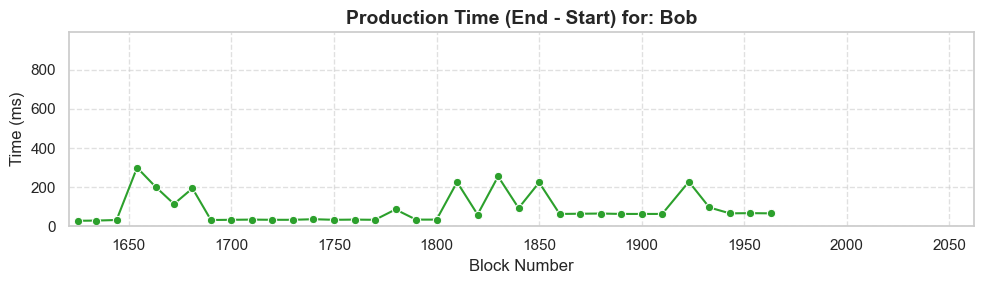

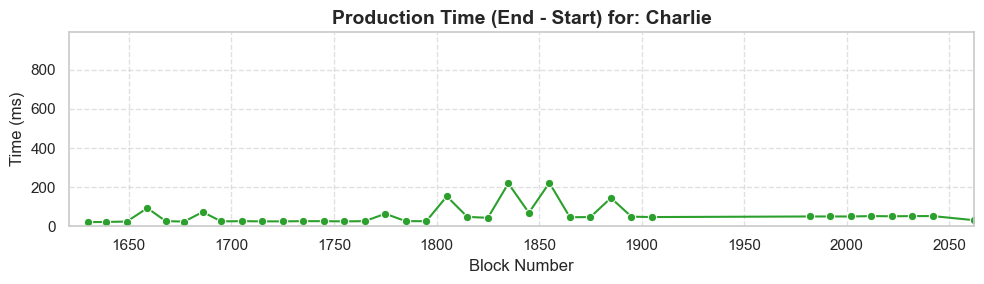

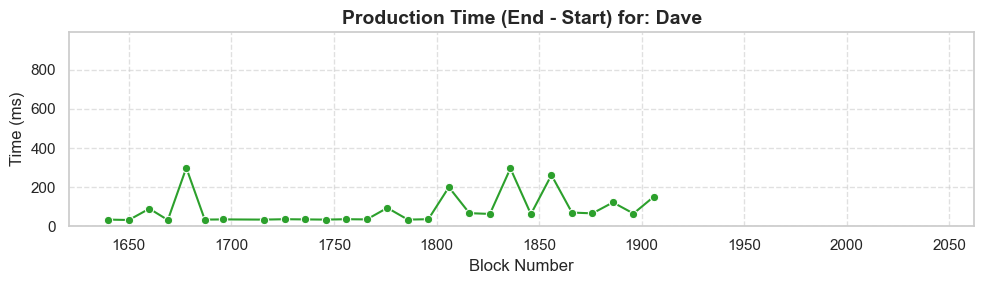

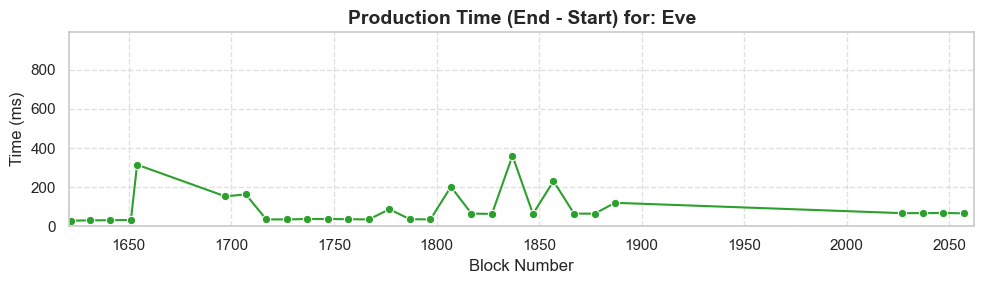

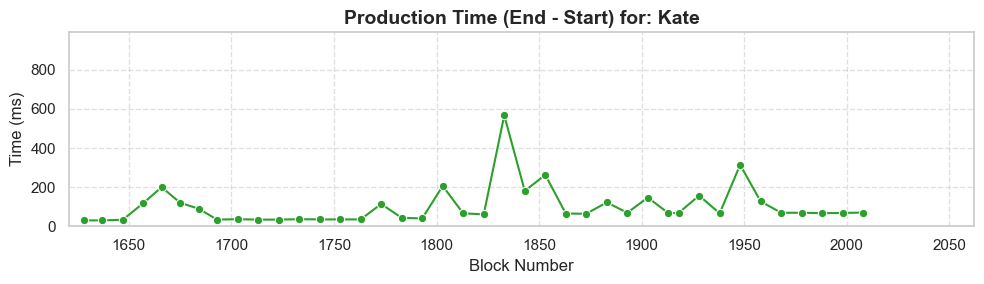

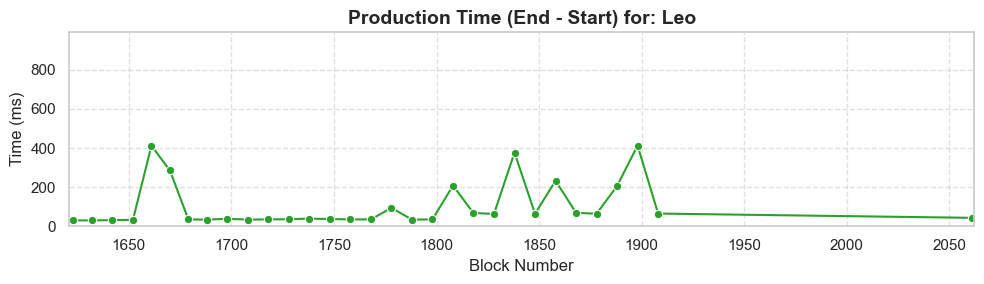

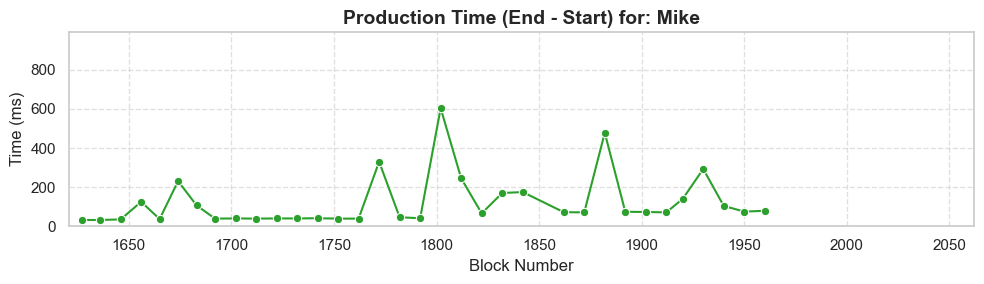

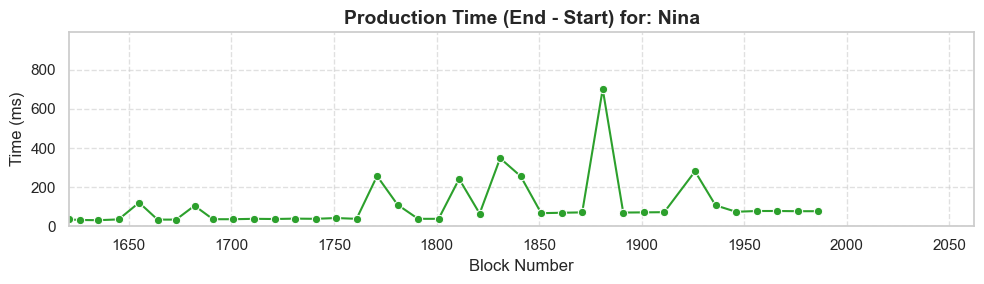

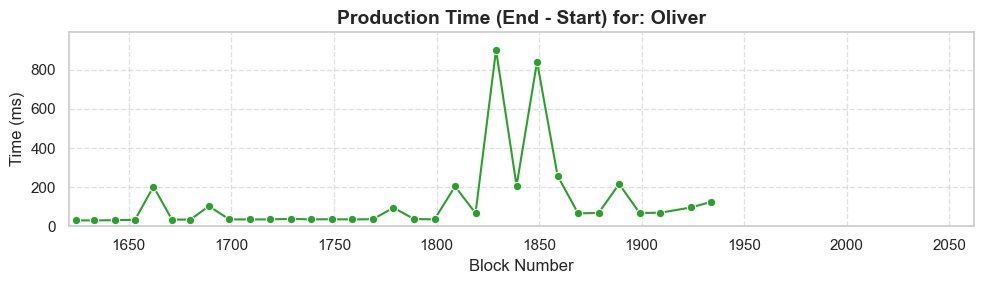

In [50]:
#===================================================================================
# Plot each Block Producer's block production time
#===================================================================================

# 1. Get the list of nodes
unique_nodes = sorted(df['Node'].unique())

# 2. Determine global X-axis limits
min_block = df['Block'].min()
max_block = df['Block'].max()

# 3. Determine global Y-axis limit (New Step)
# Find the max time across ALL nodes and add a 10% buffer for visual spacing
max_y_val = df['ProductionTime_ms'].max()
global_y_limit = max_y_val * 1.1 

# 4. Iterate and plot
for node in unique_nodes:
    # Filter data for this specific node
    node_data = df[df['Node'] == node]
    
    # Skip if no data for this node
    if node_data.empty:
        continue

    # Create a new figure for each node
    plt.figure(figsize=(10, 3))
    
    # Plot Production Time
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ProductionTime_ms", 
        marker="o", 
        color="#2ca02c"
    )
    
    # Formatting
    plt.title(f"Production Time (End - Start) for: {node}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- GLOBAL AXIS LIMITS ---
    # 1. Apply global X limits
    plt.xlim(min_block, max_block)
    
    # 2. Apply global Y limits (0 to Global Max)
    plt.ylim(0, global_y_limit)
    # --------------------------
    
    # Handle ticks: If the total range is small, show every integer. 
    if (max_block - min_block) < 50:
        plt.xticks(range(int(min_block), int(max_block) + 1))
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Reading logs from: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00
Processing complete.
  - Unique Blocks Created: 339
  - Total Import Events: 3356

Sample Data (First 5 rows):
      Block   Node  ImportTime_ms         Hash
0      1621  alice          284.0  0x4411…9414
1218   1621    eve          261.0  0x4411…9414
1464   1621   kate          269.0  0x4411…9414
315    1621    bob          263.0  0x4411…9414
1792   1621    leo          163.0  0x4411…9414

Graph saved as 'import_times_hash_matched.png'


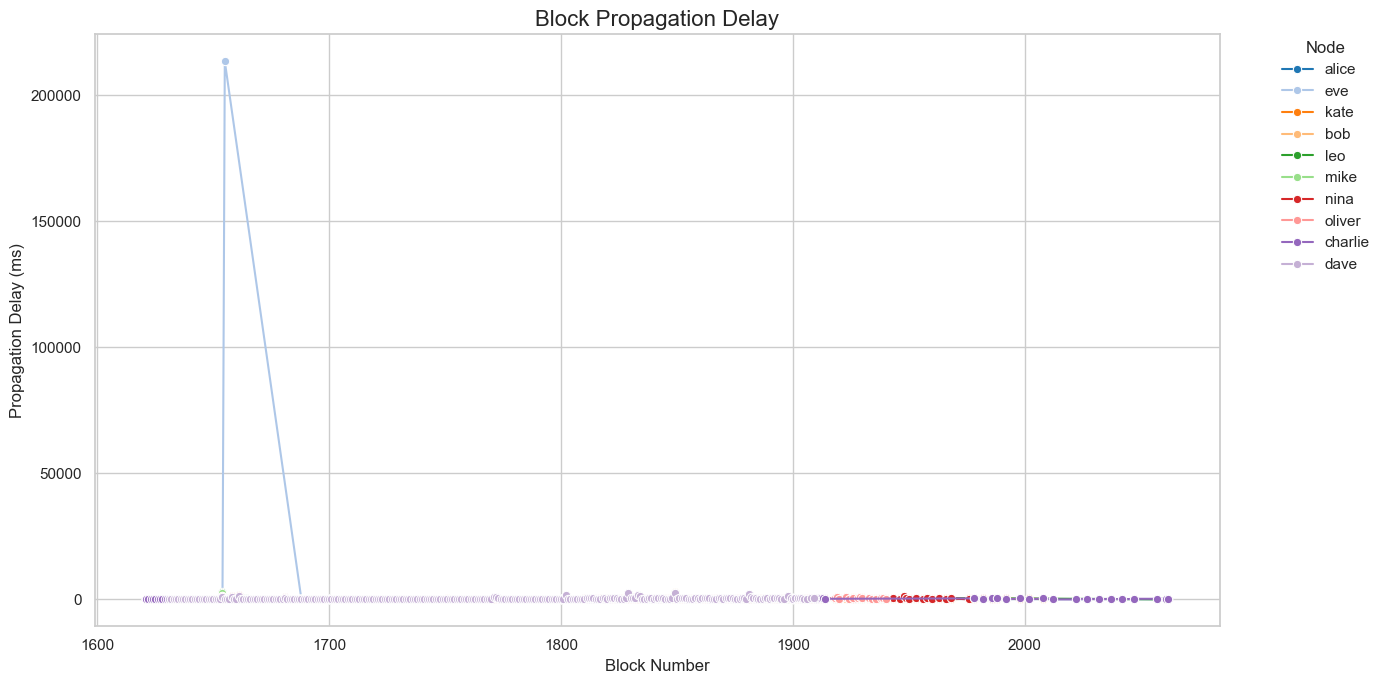

In [51]:
# ---------------------------------------------------------
# Plot all block import times
# ---------------------------------------------------------




# ---------------------------------------------------------
# STEP 2: HELPER FUNCTIONS
# ---------------------------------------------------------

def to_short_hash(full_hash):
    """
    Converts a full hash (e.g. 0xf2d38b...ed171) to the log format (0xf2d3…d171).
    Standard Substrate log format is usually: 0x + first 4 + … + last 4
    """
    if not full_hash.startswith("0x"):
        return full_hash
    
    # Remove 0x prefix for slicing
    clean = full_hash[2:]
    if len(clean) < 8: return full_hash
    
    return f"0x{clean[:4]}…{clean[-4:]}"

# ---------------------------------------------------------
# STEP 3: PARSE THE FILES
# ---------------------------------------------------------

# Dictionary to store creation times keyed by the BLOCK HASH (Short format)
# Key: ShortHash (str), Value: { 'time': datetime, 'block_num': int, 'node': str }
creation_registry = {}

# List to store raw import events to be processed later
# Item: { 'time': datetime, 'block_num': int, 'short_hash': str, 'node': str }
import_events = []

# Regex patterns
timestamp_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)")

# Capture Creation: "Pre-sealed block for proposal at 3040. Hash now 0xf2d3..."
# We use the "Pre-sealed" line because it contains the final finalized hash.
creation_pattern = re.compile(r"Pre-sealed block for proposal at (\d+)\. Hash now (0x[a-fA-F0-9]+)")

# Capture Import: "Imported #3040 (0x4e7c…cc64 → 0xf2d3…d171)"
# We capture Group 1 (Block Num) and Group 2 (The second hash, which is the new block hash)
import_pattern = re.compile(r"Imported #(\d+) \(.*? → (0x[a-fA-F0-9…\.]+)\)")

print(f"Reading logs from: {LOG_DIR}")

for node in NODES:
    filepath = os.path.join(LOG_DIR, f"{node}.txt")
    
    if not os.path.exists(filepath):
        print(f"  - Warning: Log file not found for {node}")
        continue
        
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            
            # 1. Extract Timestamp
            ts_match = timestamp_pattern.search(line)
            if not ts_match: continue
            
            try:
                ts_str = ts_match.group(1)
                # Truncate microseconds if too long (Python limit)
                if len(ts_str.split('.')[-1]) > 6: ts_str = ts_str[:26] 
                current_time = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
            except ValueError:
                continue 

            # 2. Check for BLOCK CREATION (The Source of Truth)
            create_match = creation_pattern.search(line)
            if create_match:
                block_num = int(create_match.group(1))
                full_hash = create_match.group(2)
                short_hash = to_short_hash(full_hash)
                
                # We store this hash as the canonical creation event
                creation_registry[short_hash] = {
                    'time': current_time,
                    'block_num': block_num,
                    'creator': node
                }
                continue

            # 3. Check for BLOCK IMPORT
            import_match = import_pattern.search(line)
            if import_match:
                block_num = int(import_match.group(1))
                imported_hash = import_match.group(2)
                
                import_events.append({
                    'time': current_time,
                    'block_num': block_num,
                    'short_hash': imported_hash,
                    'node': node
                })

print(f"Processing complete.")
print(f"  - Unique Blocks Created: {len(creation_registry)}")
print(f"  - Total Import Events: {len(import_events)}")

# ---------------------------------------------------------
# STEP 4: CALCULATE LATENCY (MATCHING BY HASH)
# ---------------------------------------------------------

data = []

for event in import_events:
    target_hash = event['short_hash']
    importer = event['node']
    import_time = event['time']
    
    # Only calculate if we have a creation record for THIS SPECIFIC HASH
    if target_hash in creation_registry:
        genesis_info = creation_registry[target_hash]
        creation_time = genesis_info['time']
        creator = genesis_info['creator']
        block_num = genesis_info['block_num']
        
        # If this node is the creator, latency is 0
        if importer == creator:
            delay_ms = 0.0
        else:
            delta = import_time - creation_time
            delay_ms = delta.total_seconds() * 1000.0
        
        data.append({
            "Block": block_num,
            "Node": importer,
            "ImportTime_ms": delay_ms,
            "Hash": target_hash
        })

# ---------------------------------------------------------
# STEP 5: PLOT
# ---------------------------------------------------------

if not data:
    print("No matching hash data found! Check if the log format matches the patterns.")
else:
    df = pd.DataFrame(data)
    df = df.sort_values(by="Block")
    
    # Display sample to verify
    print("\nSample Data (First 5 rows):")
    print(df.head())

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    sns.lineplot(
        data=df, 
        x="Block", 
        y="ImportTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab20", 
        linewidth=1.5,
        errorbar=None 
    )

    plt.title("Block Propagation Delay", fontsize=16)
    plt.xlabel("Block Number", fontsize=12)
    plt.ylabel("Propagation Delay (ms)", fontsize=12)
    
    # Formatting X-axis
    if df["Block"].nunique() < 20:
        plt.xticks(df["Block"].unique())

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Node")
    plt.tight_layout()
    
    plt.savefig("import_times_hash_matched.png", dpi=300)
    print("\nGraph saved as 'import_times_hash_matched.png'")
    
    plt.show()

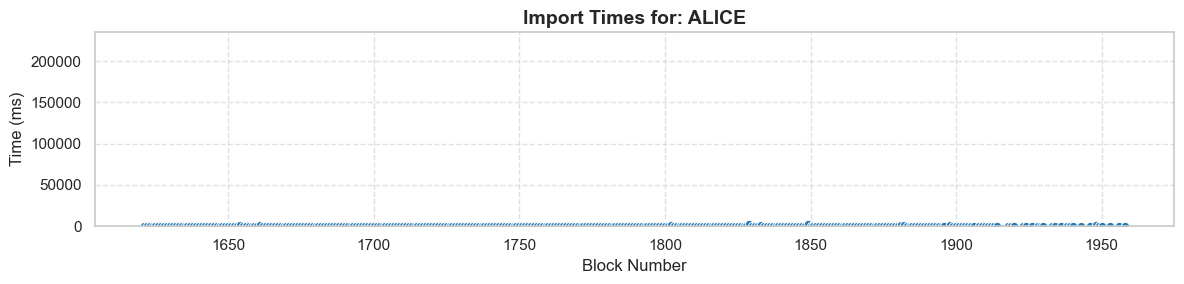

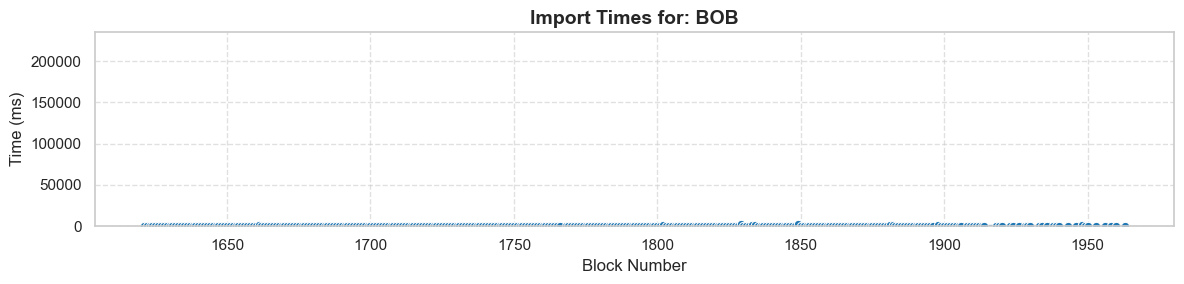

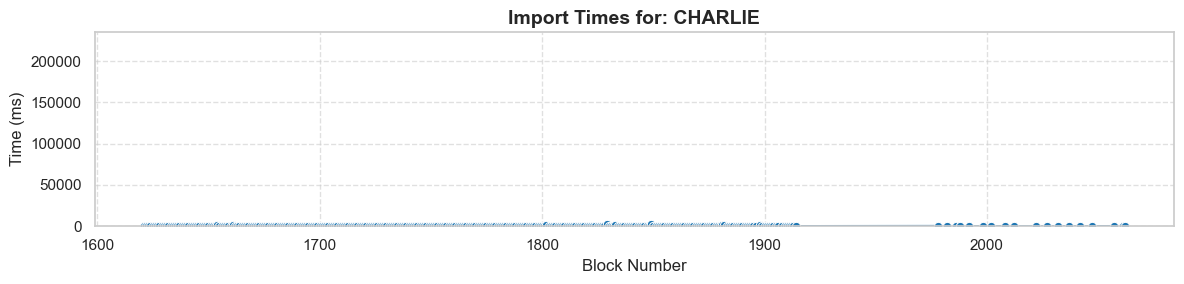

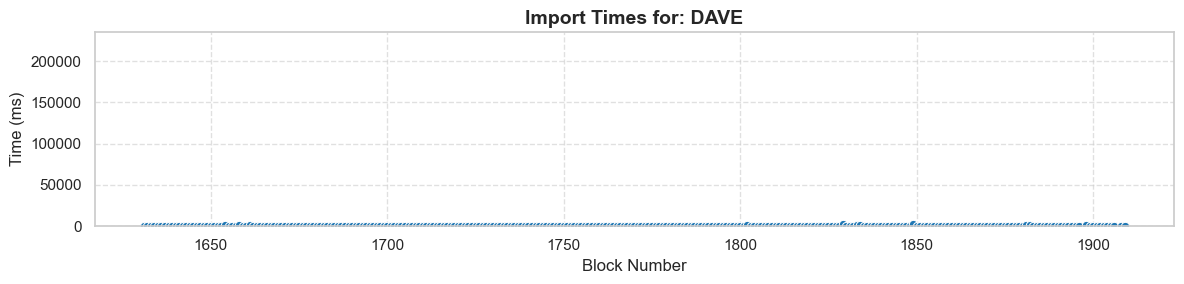

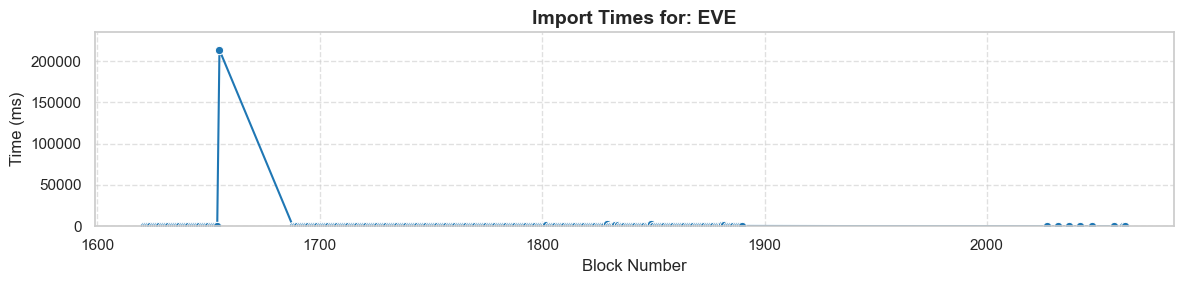

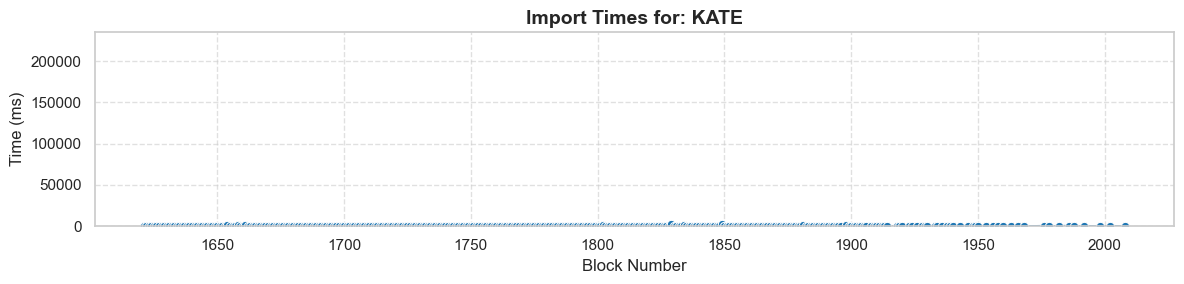

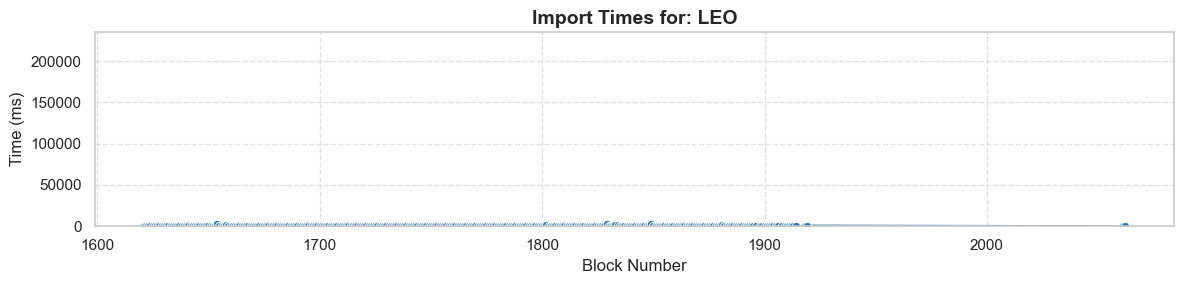

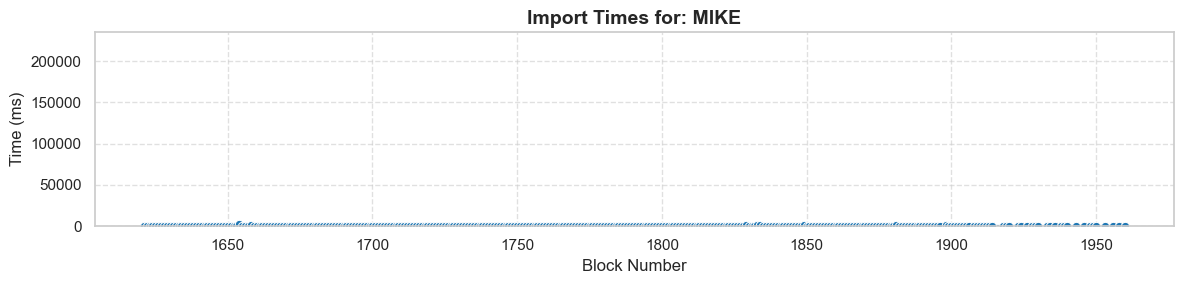

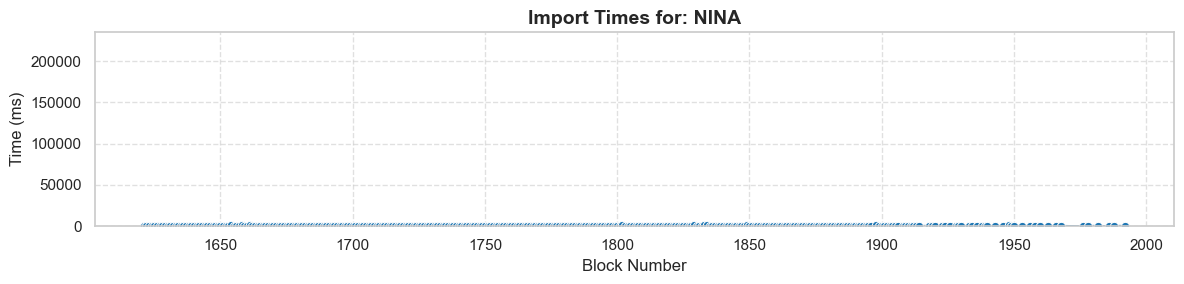

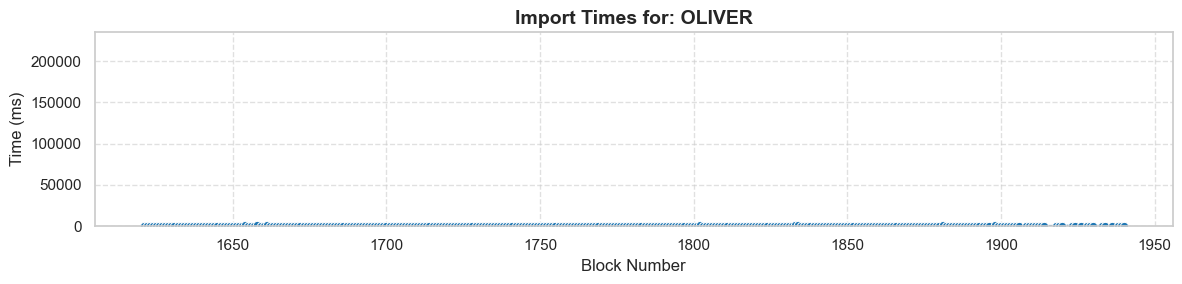

In [52]:
# ---------------------------------------------------------
# Plot block import times per node
# ---------------------------------------------------------


# 1. PRE-CALCULATE THE Y-AXIS LIMIT
# Find the max value in the whole dataset and add a 10% buffer for visual spacing
max_val = df['ImportTime_ms'].max()
global_y_limit = max_val * 1.1 

# Get a list of all unique nodes and sort them alphabetically
nodes = sorted(df['Node'].unique())

# Loop through each node and create a separate graph
for node in nodes:
    # Filter the data for just this node
    node_data = df[df['Node'] == node]
    
    # Create a new figure for this node
    plt.figure(figsize=(12, 3)) 
    
    # Plot the line
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ImportTime_ms", 
        marker="o",
        color='tab:blue',
        errorbar=None
    )
    
    # Formatting
    plt.title(f"Import Times for: {node.upper()}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # --- CRITICAL CHANGE HERE ---
    # Force every plot to use the same 0 to Global Max scale
    plt.ylim(0, global_y_limit)
    # ----------------------------
    
    # Ensure X-axis shows every block integer (if list isn't too long)
    if len(df["Block"].unique()) < 50:
        plt.xticks(df["Block"].unique())
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Display the graph
    plt.show()






# Block Size Analysis

This section analyzes block sizes by fetching data directly from the node. No intermediate CSV file is required.

## Configuration & Data Fetching

Configure the node URL and the range of blocks you want to analyze below.

In [ ]:

# FORCE RELOAD to pick up any changes to the scripts on disk
importlib.reload(fetch_block_sizes)
importlib.reload(extract_block_range_from_logs)

# ==========================================
# CONFIGURATION
# ==========================================
NODE_URL = "ws://george.node.sc.iog.io:9944"

print(f"Using LOG_DIR: {LOG_DIR}")

# AUTOMATIC RANGE DETECTION
# If valid block range is found from logs, we prioritize that over LATEST_N
try:
    print("Extracting block range from logs...")
    
    from datetime import datetime, timezone, timedelta
    
    # Default to a wide range in UTC
    start_time = datetime(2020, 1, 1, tzinfo=timezone.utc)
    end_time = datetime(2030, 1, 1, tzinfo=timezone.utc)
    
    # Try to parse from directory name 'from_YYYY..._to_YYYY...'
    log_dir_name = os.path.basename(LOG_DIR.rstrip('/'))
    if log_dir_name.startswith('from_') and '_to_' in log_dir_name:
        try:
            parts = log_dir_name.split('_to_')
            start_str = parts[0].replace('from_', '')
            end_str = parts[1]
            
            # Assume directory times are EST (UTC-5) as per common workflow
            est_tz = timezone(timedelta(hours=-5))
            
            # Format: YYYY-MM-DD_HH-MM-SS
            dt_start = datetime.strptime(start_str, "%Y-%m-%d_%H-%M-%S").replace(tzinfo=est_tz)
            dt_end = datetime.strptime(end_str, "%Y-%m-%d_%H-%M-%S").replace(tzinfo=est_tz)
            
            # Convert to UTC
            start_time = dt_start.astimezone(timezone.utc)
            end_time = dt_end.astimezone(timezone.utc)
            
            print(f"Inferred time range from directory (EST -> UTC):")
            print(f"  Input: {start_str} to {end_str} (EST)")
            print(f"  UTC:   {start_time} to {end_time}")
        except ValueError as e:
            print(f"Could not parse time range from directory name ({e}), using default wide range.")

    # Find the range
    start_block, end_block = extract_block_range_from_logs.find_block_range_from_logs(
        LOG_DIR, start_time, end_time, min_block_threshold=0
    )
    
    print(f"Found block range from logs: #{start_block} to #{end_block}")
    
    # Disable LATEST_N if range is found
    LATEST_N = None
    START_BLOCK = start_block
    END_BLOCK = end_block
    
except Exception as e:
    print(f"Error extracting block range from logs: {e}")
    print("Falling back to LATEST_N configuration.")
    LATEST_N = 100
    START_BLOCK = None
    END_BLOCK = None

# ==========================================
# FETCH DATA
# ==========================================
try:
    print(f"Connecting to node at {NODE_URL}...")
    substrate = fetch_block_sizes.connect_to_node(NODE_URL)
    
    if LATEST_N:
        print(f"Fetching latest {LATEST_N} blocks...")
        block_data = fetch_block_sizes.fetch_latest_n_blocks(substrate, LATEST_N)
    elif START_BLOCK is not None and END_BLOCK is not None:
        print(f"Fetching blocks #{START_BLOCK} to #{END_BLOCK} ({END_BLOCK - START_BLOCK + 1} blocks)...")
        block_data = fetch_block_sizes.fetch_block_range(substrate, START_BLOCK, END_BLOCK)
    else:
        print("No valid block range or LATEST_N specified.")
        block_data = []

    substrate.close()
    
    # Convert to DataFrame
    df = pd.DataFrame(block_data)
    
    # Display info
    print(f"\nSuccessfully loaded {len(df)} blocks")
    if not df.empty:
        print(f"Block range: #{df['block_number'].min()} to #{df['block_number'].max()}")
        display(df.head())
    else:
        print("No block data fetched.")

except Exception as e:
    print(f"Error fetching data: {e}")
    import traceback
    traceback.print_exc()
    # Create empty dataframe to prevent errors in subsequent cells
    df = pd.DataFrame(columns=['block_number', 'block_hash', 'size_bytes', 'size_kb', 'size_mb', 'extrinsic_count', 'timestamp'])

Using LOG_DIR: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00
Extracting block range from logs...
Inferred time range from directory (EST -> UTC):
  Input: 2026-01-28_13-30-00 to 2026-01-28_14-15-00 (EST)
  UTC:   2026-01-28 18:30:00+00:00 to 2026-01-28 19:15:00+00:00


Scanning 23 log file(s)... (min block: 0)
  leo.txt: found 308 blocks
  iris.txt: found 393 blocks
  rita.txt: found 399 blocks
  tom.txt: found 410 blocks
  eve.txt: found 285 blocks
  dave.txt: found 285 blocks
  paul.txt: found 405 blocks
  george.txt: found 397 blocks
  oliver.txt: found 322 blocks
  alice.txt: found 338 blocks
  bob.txt: found 346 blocks
  kate.txt: found 389 blocks
  charlie.txt: found 383 blocks
  henry.txt: found 426 blocks
  nina.txt: found 374 blocks
  mike.txt: found 341 blocks
  sam.txt: found 392 blocks
  quinn.txt: found 390 blocks
  ferdie.txt: found 406 blocks
  jack.txt: found 370 blocks


Found block range from logs: #1476 to #2065
Connecting to node at ws://george.node.sc.iog.io:9944...
Connecting to node at ws://george.node.sc.iog.io:9944...
Connected successfully!
Chain: Midnight Perfnet
Fetching blocks #1476 to #2065 (590 blocks)...

Fetching blocks 1476 to 2065 (590 blocks)...
Progress: 4.6% - Block #1502: 0.82 KB (2 extrinsics))

## Summary Statistics

In [ ]:
print("=" * 60)
print("BLOCK SIZE STATISTICS")
print("=" * 60)
print(f"Average block size:     {df['size_kb'].mean():.2f} KB")
print(f"Median block size:      {df['size_kb'].median():.2f} KB")
print(f"Min block size:         {df['size_kb'].min():.2f} KB")
print(f"Max block size:         {df['size_kb'].max():.2f} KB")
print(f"Std deviation:          {df['size_kb'].std():.2f} KB")
print(f"Total data:             {df['size_mb'].sum():.2f} MB")
print()
print("EXTRINSIC STATISTICS")
print("=" * 60)
print(f"Total extrinsics:       {df['extrinsic_count'].sum():,}")
print(f"Average per block:      {df['extrinsic_count'].mean():.1f}")
print(f"Min per block:          {df['extrinsic_count'].min()}")
print(f"Max per block:          {df['extrinsic_count'].max()}")

## Block Size Over Time

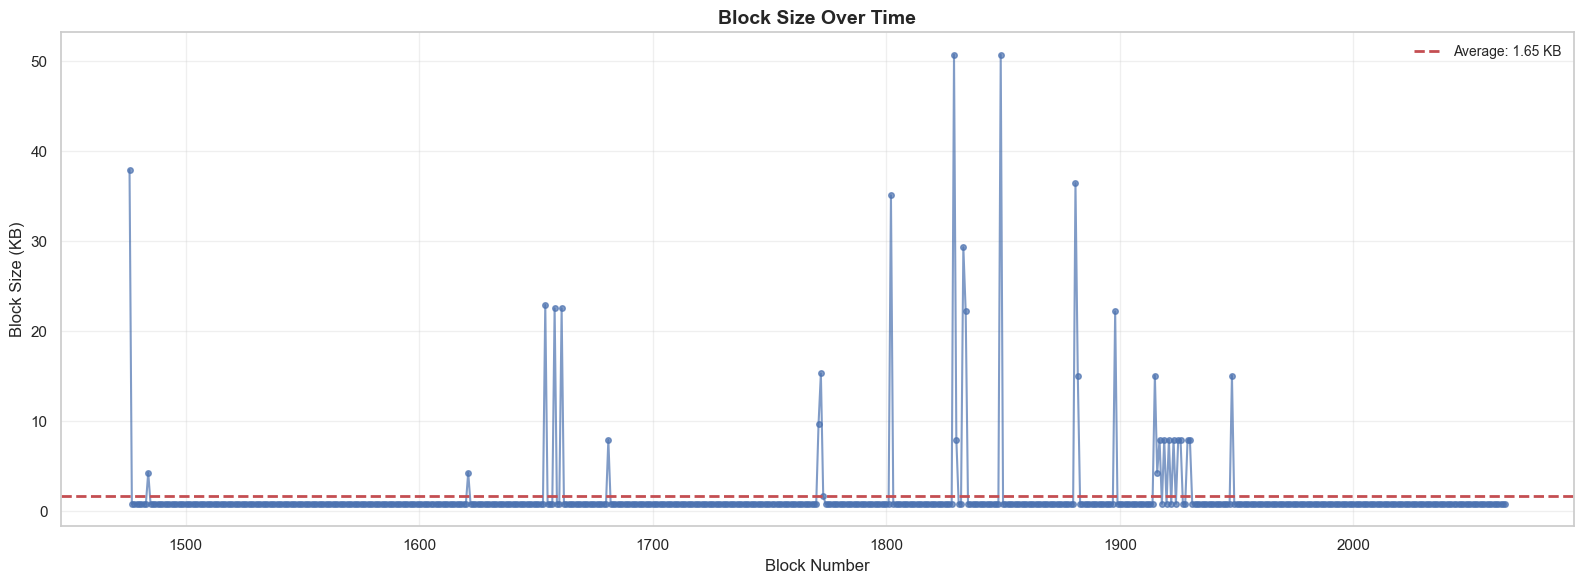

In [29]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_kb'], marker='o', markersize=4, linewidth=1.5, alpha=0.7)
ax.axhline(y=df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label=f"Average: {df['size_kb'].mean():.2f} KB")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Block Size Distribution

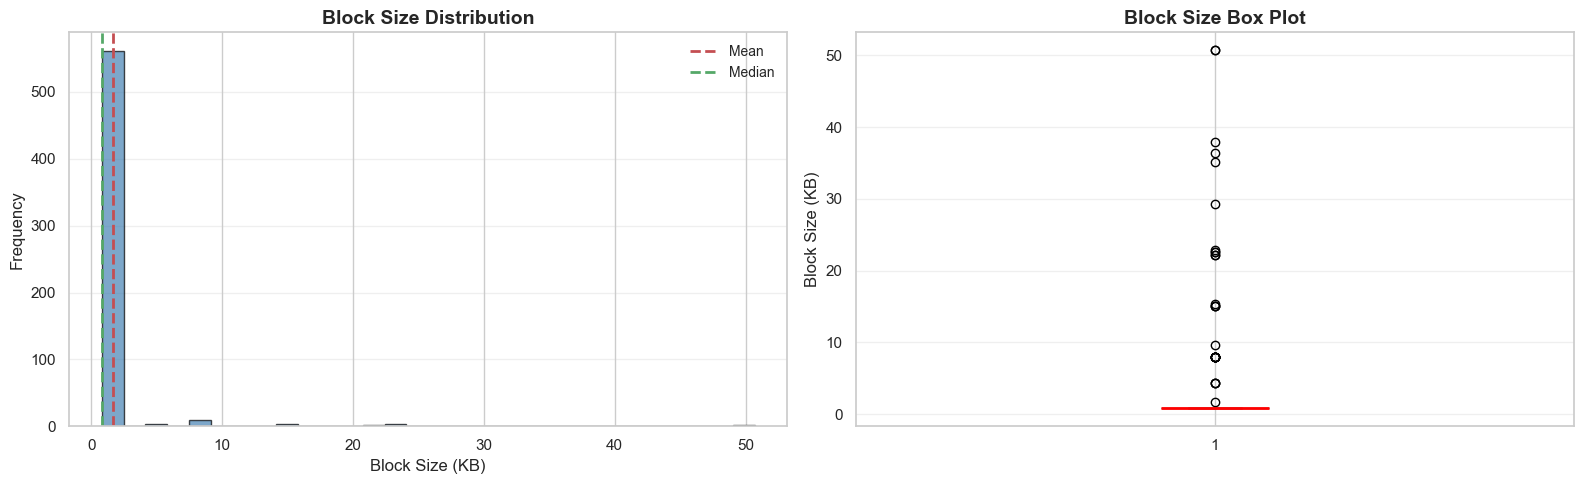

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax1.hist(df['size_kb'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(df['size_kb'].mean(), color='r', linestyle='--', linewidth=2, label='Mean')
ax1.axvline(df['size_kb'].median(), color='g', linestyle='--', linewidth=2, label='Median')
ax1.set_xlabel('Block Size (KB)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Block Size Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Box plot
ax2.boxplot(df['size_kb'], vert=True, patch_artist=True, 
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Block Size (KB)', fontsize=12)
ax2.set_title('Block Size Box Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df['extrinsic_count'], df['size_kb'], alpha=0.6, s=60, edgecolors='black', linewidth=0.5)

# Add trend line
if len(df) > 1:
    z = np.polyfit(df['extrinsic_count'], df['size_kb'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df['extrinsic_count'].min(), df['extrinsic_count'].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.2f}')

ax.set_xlabel('Number of Extrinsics', fontsize=12)
ax.set_ylabel('Block Size (KB)', fontsize=12)
ax.set_title('Block Size vs Number of Extrinsics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Top 10 Largest Blocks

In [31]:
top_blocks = df.nlargest(10, 'size_kb')[['block_number', 'size_kb', 'extrinsic_count']]
top_blocks.reset_index(drop=True, inplace=True)
top_blocks.index = top_blocks.index + 1
print("Top 10 Largest Blocks:")
print(top_blocks.to_string())

Top 10 Largest Blocks:
    block_number    size_kb  extrinsic_count
1           1829  50.693359                9
2           1849  50.689453                9
3           1476  37.906250                7
4           1881  36.441406                7
5           1802  35.089844               12
6           1833  29.314453                6
7           1654  22.904297                5
8           1658  22.533203                5
9           1661  22.533203                5
10          1834  22.193359                5


## Size per Extrinsic Analysis

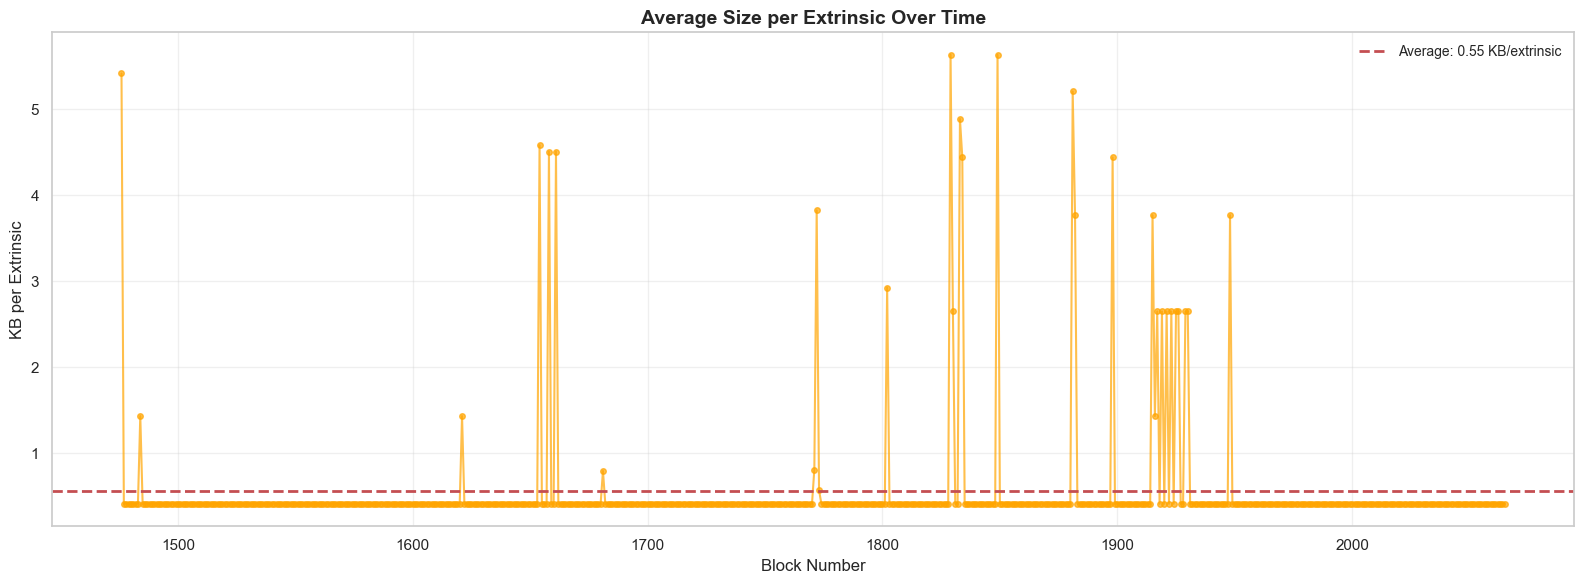

In [32]:
# Calculate average size per extrinsic for each block
df['size_per_extrinsic'] = df['size_kb'] / df['extrinsic_count'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df['block_number'], df['size_per_extrinsic'], marker='o', markersize=4, linewidth=1.5, alpha=0.7, color='orange')
ax.axhline(y=df['size_per_extrinsic'].mean(), color='r', linestyle='--', linewidth=2, 
           label=f"Average: {df['size_per_extrinsic'].mean():.2f} KB/extrinsic")

ax.set_xlabel('Block Number', fontsize=12)
ax.set_ylabel('KB per Extrinsic', fontsize=12)
ax.set_title('Average Size per Extrinsic Over Time', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mempool Benchmark Analysis

In [33]:
import sys
import os

# Add mempool_benchmarks to path
mempool_lib_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'mempool_benchmarks'))
if mempool_lib_path not in sys.path:
    sys.path.append(mempool_lib_path)

import extractor
import analyzer
import importlib
importlib.reload(extractor)
importlib.reload(analyzer)

# Save current directory and change to log directory
original_dir = os.getcwd()
os.chdir(LOG_DIR)

try:
    nodes = ['ferdie']  # Default node with detailed txpool logs
    events = extractor.parse_logs(nodes)
    print(f'Found {len(events)} mempool events')
    
    # Generate report
    report = extractor.generate_report(events)
    with open('mempool_report.txt', 'w') as f:
        f.write(report)
    
    # Export CSV
    extractor.export_events_csv(events, 'mempool_events.csv')
    print('Mempool metrics extracted to mempool_report.txt and mempool_events.csv')
finally:
    # Always restore original directory
    os.chdir(original_dir)

NameError: name 'extractor' is not defined

In [34]:
# Parse the report and create dataframes (from LOG_DIR)
mempool_report_path = os.path.join(LOG_DIR, 'mempool_report.txt')
mempool_points = analyzer.parse_report(mempool_report_path)
mempool_df = analyzer.to_dataframe(mempool_points)
mempool_resampled = analyzer.resample_metrics(mempool_df, window_ms=1000)

# Generate summary and insights
mempool_summary = analyzer.summarize(mempool_resampled, mempool_df)
mempool_insights = analyzer.generate_insights(mempool_resampled, mempool_df)

# Save analysis to LOG_DIR
analysis_path = os.path.join(LOG_DIR, 'mempool_analysis.txt')
with open(analysis_path, 'w') as f:
    f.write('# Mempool Analysis\n\n')
    f.write('Window: 1000 ms\n\n')
    f.write(mempool_summary)
    f.write('\n\n')
    f.write(mempool_insights)

# Export CSV for graphing
csv_path = os.path.join(LOG_DIR, 'mempool_analysis_timeseries.csv')
analyzer.export_csv(mempool_resampled, csv_path)
print(f'Mempool analysis complete. Files saved to {LOG_DIR}')

NameError: name 'analyzer' is not defined

# Mempool Benchmark Analysis

This section analyzes mempool metrics for both Charlie and Ferdie nodes.

In [35]:
# === CHARLIE NODE ANALYSIS ===
print('\n=== CHARLIE NODE MEMPOOL METRICS ===\n')

# Load Charlie's time series data
csv_path_charlie = os.path.join(LOG_DIR, 'mempool_analysis_charlie_timeseries.csv')
if os.path.exists(csv_path_charlie):
    mempool_ts_charlie = pd.read_csv(csv_path_charlie)
    mempool_ts_charlie['timestamp'] = pd.to_datetime(mempool_ts_charlie['timestamp'])
    
    # Create 4-panel visualization for Charlie
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Charlie Node - Mempool Metrics Over Time', fontsize=16, fontweight='bold')
    fig.patch.set_facecolor('lightgreen')
    [ax.set_facecolor('lightgreen') for ax in axes.ravel()]
    
    # Plot each metric
    axes[0,0].plot(mempool_ts_charlie['timestamp'], mempool_ts_charlie['ready'], 'b-', linewidth=0.8)
    axes[0,0].set_title('Ready Transactions')
    axes[0,0].set_ylabel('Count')
    axes[0,0].grid(True, alpha=0.3)
    
    axes[0,1].plot(mempool_ts_charlie['timestamp'], mempool_ts_charlie['future'], 'r-', linewidth=0.8)
    axes[0,1].set_title('Future Transactions')
    axes[0,1].set_ylabel('Count')
    axes[0,1].grid(True, alpha=0.3)
    
    axes[1,0].plot(mempool_ts_charlie['timestamp'], mempool_ts_charlie['mempool_len'], 'g-', linewidth=0.8)
    axes[1,0].set_title('Total Mempool Length')
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_xlabel('Time')
    axes[1,0].grid(True, alpha=0.3)
    
    axes[1,1].plot(mempool_ts_charlie['timestamp'], mempool_ts_charlie['admission_tps'], 'purple', linewidth=0.8)
    axes[1,1].set_title('Transaction Admission Rate')
    axes[1,1].set_ylabel('TPS')
    axes[1,1].set_xlabel('Time')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f'Warning: Charlie timeseries data not found at {csv_path_charlie}')


=== CHARLIE NODE MEMPOOL METRICS ===



In [36]:
# Display Charlie's analysis report
analysis_path_charlie = os.path.join(LOG_DIR, 'mempool_analysis_charlie.txt')
if os.path.exists(analysis_path_charlie):
    with open(analysis_path_charlie, 'r') as f:
        print(f.read())
else:
    print(f'Warning: Charlie analysis report not found at {analysis_path_charlie}')

In [37]:
# === FERDIE NODE ANALYSIS ===
print('\n=== FERDIE NODE MEMPOOL METRICS ===\n')

# Load Ferdie's time series data
csv_path_ferdie = os.path.join(LOG_DIR, 'mempool_analysis_ferdie_timeseries.csv')
if os.path.exists(csv_path_ferdie):
    mempool_ts_ferdie = pd.read_csv(csv_path_ferdie)
    mempool_ts_ferdie['timestamp'] = pd.to_datetime(mempool_ts_ferdie['timestamp'])
    
    # Create 4-panel visualization for Ferdie
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Ferdie Node - Mempool Metrics Over Time', fontsize=16, fontweight='bold')
    fig.patch.set_facecolor('lightblue')
    [ax.set_facecolor('lightblue') for ax in axes.ravel()]
    
    # Plot each metric
    axes[0,0].plot(mempool_ts_ferdie['timestamp'], mempool_ts_ferdie['ready'], 'b-', linewidth=0.8)
    axes[0,0].set_title('Ready Transactions')
    axes[0,0].set_ylabel('Count')
    axes[0,0].grid(True, alpha=0.3)
    
    axes[0,1].plot(mempool_ts_ferdie['timestamp'], mempool_ts_ferdie['future'], 'r-', linewidth=0.8)
    axes[0,1].set_title('Future Transactions')
    axes[0,1].set_ylabel('Count')
    axes[0,1].grid(True, alpha=0.3)
    
    axes[1,0].plot(mempool_ts_ferdie['timestamp'], mempool_ts_ferdie['mempool_len'], 'g-', linewidth=0.8)
    axes[1,0].set_title('Total Mempool Length')
    axes[1,0].set_ylabel('Count')
    axes[1,0].set_xlabel('Time')
    axes[1,0].grid(True, alpha=0.3)
    
    axes[1,1].plot(mempool_ts_ferdie['timestamp'], mempool_ts_ferdie['admission_tps'], 'purple', linewidth=0.8)
    axes[1,1].set_title('Transaction Admission Rate')
    axes[1,1].set_ylabel('TPS')
    axes[1,1].set_xlabel('Time')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f'Warning: Ferdie timeseries data not found at {csv_path_ferdie}')


=== FERDIE NODE MEMPOOL METRICS ===



In [38]:
# Display Ferdie's analysis report
analysis_path_ferdie = os.path.join(LOG_DIR, 'mempool_analysis_ferdie.txt')
if os.path.exists(analysis_path_ferdie):
    with open(analysis_path_ferdie, 'r') as f:
        print(f.read())
else:
    print(f'Warning: Ferdie analysis report not found at {analysis_path_ferdie}')

In [39]:
# Your custom analysis here

## Forks




Reading logs from: /Users/larry/Project/iohk/partner-chains/e2e-tests/utils/benchmarks/logs/from_2026-01-28_13-30-00_to_2026-01-28_14-15-00
Processed 10 files.
  Raw block imports: 3356
  After dedup: 3356 (removed 0 duplicates)
  Finalization events: 4138

Height range: 1477 to 2065
Time range: 2026-01-28 18:30:00.098000 to 2026-01-28 19:14:54.456000

SUMMARY

--- Unique blocks per node per height ---
Series([], Name: Hash, dtype: int64)

--- Max Total Concurrent Tips per Node ---
Node
Alice      4
Bob        4
Charlie    4
Dave       4
Eve        4
Kate       4
Leo        4
Mike       4
Nina       4
Oliver     4
Name: TotalTips, dtype: int64

Overall max concurrent tips: 4

--- Max Fork Depth (at single height) per Node ---
Node
Alice      1
Bob        1
Charlie    1
Dave       1
Eve        1
Kate       1
Leo        1
Mike       1
Nina       1
Oliver     1
Name: MaxAtHeight, dtype: int64

Overall max fork depth: 1


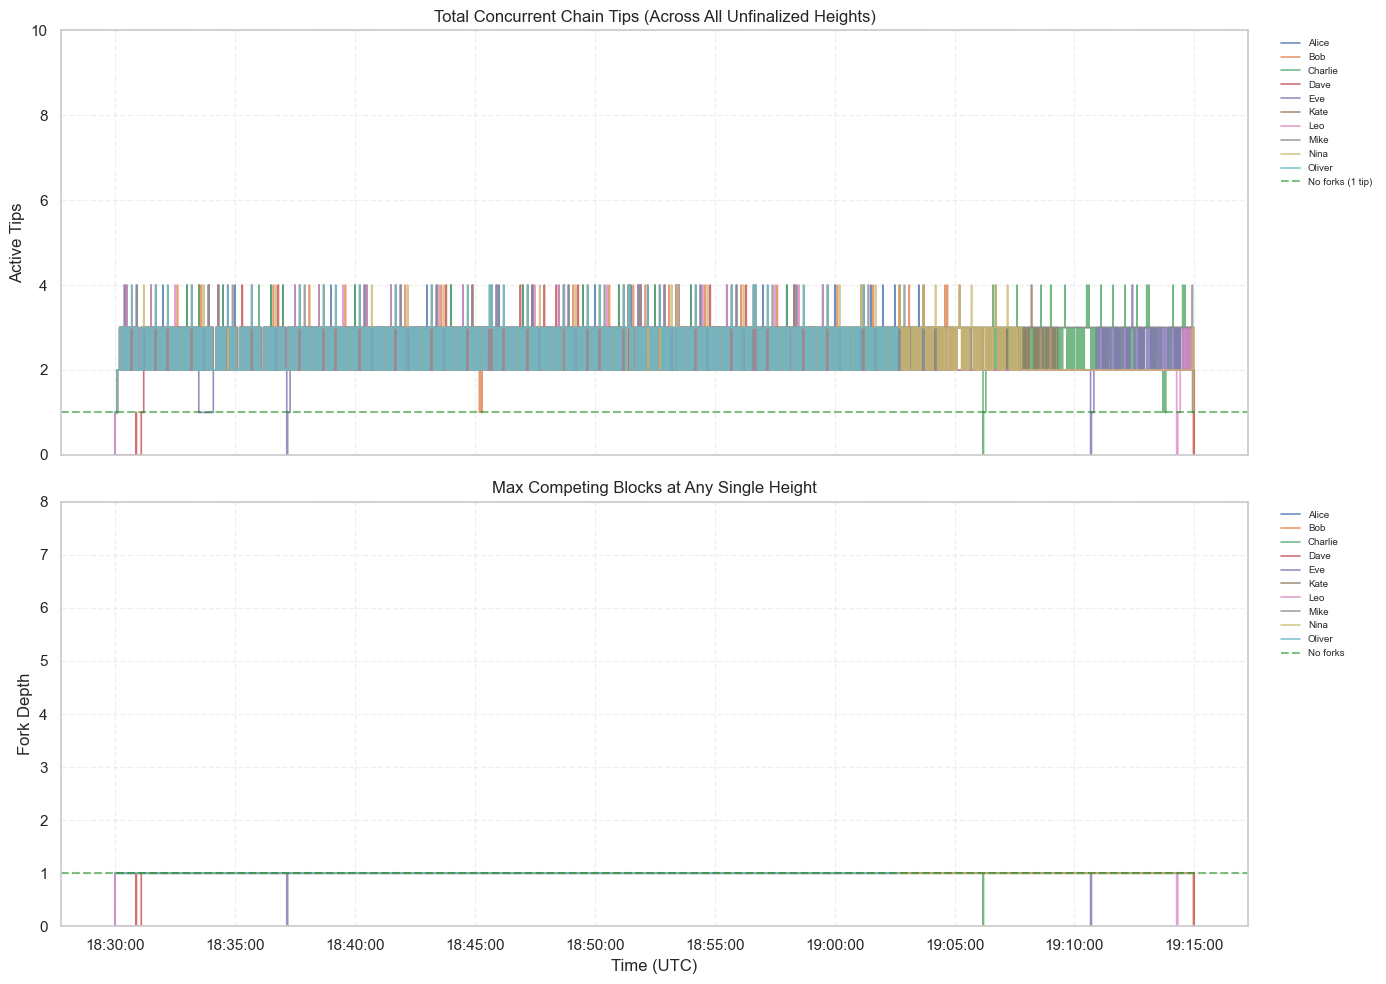

In [40]:
# Regex for block imports
log_pattern = re.compile(
    r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*?'
    r'Imported #(\d+)\s*'
    r'\((0x[a-f0-9]{4})[^\)]*?'
    r'(?:→|->|\xe2\x86\x92)\s*'
    r'(0x[a-f0-9]{4})[^\)]*\)'
)

# Regex for finalization events
finalized_pattern = re.compile(
    r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3}).*?'
    r'finalized #(\d+)'
)

def load_logs(log_dir, node_list):
    imports = []
    finalizations = []
    print(f"Reading logs from: {log_dir}")
    
    files_read = 0
    for node in node_list:
        filename = f"{node}.txt"
        file_path = os.path.join(log_dir, filename)
        
        if os.path.exists(file_path):
            files_read += 1
            with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
                for line in f:
                    if "Imported #" in line:
                        match = log_pattern.search(line)
                        if match:
                            ts, height, parent, hash_prefix = match.groups()
                            dt = datetime.strptime(ts, '%Y-%m-%d %H:%M:%S.%f')
                            imports.append({
                                'Node': node.capitalize(),
                                'Time': dt,
                                'Height': int(height),
                                'Hash': hash_prefix,
                                'Parent': parent,
                            })
                    
                    if "finalized #" in line:
                        match = finalized_pattern.search(line)
                        if match:
                            ts, height = match.groups()
                            dt = datetime.strptime(ts, '%Y-%m-%d %H:%M:%S.%f')
                            finalizations.append({
                                'Node': node.capitalize(),
                                'Time': dt,
                                'FinalizedHeight': int(height),
                            })
    
    imports_df = pd.DataFrame(imports)
    finals_df = pd.DataFrame(finalizations)
    
    # CRITICAL: Deduplicate imports - keep first occurrence of each (Node, Height, Hash)
    if not imports_df.empty:
        before = len(imports_df)
        imports_df = imports_df.sort_values('Time').drop_duplicates(
            subset=['Node', 'Height', 'Hash'], 
            keep='first'
        )
        after = len(imports_df)
        print(f"Processed {files_read} files.")
        print(f"  Raw block imports: {before}")
        print(f"  After dedup: {after} (removed {before - after} duplicates)")
        print(f"  Finalization events: {len(finals_df)}")
    
    return imports_df, finals_df

def calculate_concurrent_tips(imports_df, finalizations_df):
    """
    Calculate concurrent active chain tips over time per node.
    A tip is active from when it's imported until its height is finalized.
    """
    if imports_df.empty:
        return pd.DataFrame()
    
    results = []
    
    for node in imports_df['Node'].unique():
        node_imports = imports_df[imports_df['Node'] == node].copy()
        node_finals = finalizations_df[finalizations_df['Node'] == node].copy() if not finalizations_df.empty else pd.DataFrame()
        
        # Build event timeline
        events = []
        for _, row in node_imports.iterrows():
            events.append({
                'time': row['Time'],
                'type': 'import',
                'height': row['Height'],
                'hash': row['Hash']
            })
        
        if not node_finals.empty:
            for _, row in node_finals.iterrows():
                events.append({
                    'time': row['Time'],
                    'type': 'finalize',
                    'height': row['FinalizedHeight'],
                    'hash': None
                })
        
        events.sort(key=lambda x: x['time'])
        
        # Track state
        active_blocks = {}  # (height, hash) -> True
        finalized_height = 0
        
        for evt in events:
            if evt['type'] == 'import':
                key = (evt['height'], evt['hash'])
                if key not in active_blocks:
                    active_blocks[key] = True
            
            elif evt['type'] == 'finalize':
                finalized_height = max(finalized_height, evt['height'])
                # Remove all blocks at or below finalized height
                active_blocks = {k: v for k, v in active_blocks.items() 
                                if k[0] > finalized_height}
            
            # Calculate metrics at this point in time
            if active_blocks:
                # Group by height
                by_height = {}
                for (h, bhash) in active_blocks.keys():
                    if h not in by_height:
                        by_height[h] = set()
                    by_height[h].add(bhash)
                
                # Total unique tips across all unfinalized heights
                total_tips = sum(len(hashes) for hashes in by_height.values())
                
                # Max competing at any single height
                max_at_height = max(len(hashes) for hashes in by_height.values())
                
                # Number of heights with forks (>1 block)
                forked_heights = sum(1 for hashes in by_height.values() if len(hashes) > 1)
            else:
                total_tips = 0
                max_at_height = 0
                forked_heights = 0
            
            results.append({
                'Node': node,
                'Time': evt['time'],
                'TotalTips': total_tips,
                'MaxAtHeight': max_at_height,
                'ForkedHeights': forked_heights,
                'FinalizedHeight': finalized_height,
            })
    
    return pd.DataFrame(results)

def plot_results(df):
    if df.empty:
        print("No data to plot")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    nodes = sorted(df['Node'].unique())
    
    # Plot 1: Total concurrent tips (should match Grafana)
    ax1 = axes[0]
    for node in nodes:
        node_data = df[df['Node'] == node].sort_values('Time')
        ax1.step(node_data['Time'], node_data['TotalTips'], 
                 where='post', label=node, linewidth=1.2, alpha=0.8)
    ax1.set_title("Total Concurrent Chain Tips (Across All Unfinalized Heights)")
    ax1.set_ylabel("Active Tips")
    ax1.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='No forks (1 tip)')
    ax1.set_ylim(0, 10)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    
    # Plot 2: Max forks at single height
    ax2 = axes[1]
    for node in nodes:
        node_data = df[df['Node'] == node].sort_values('Time')
        ax2.step(node_data['Time'], node_data['MaxAtHeight'], 
                 where='post', label=node, linewidth=1.2, alpha=0.8)
    ax2.set_title("Max Competing Blocks at Any Single Height")
    ax2.set_ylabel("Fork Depth")
    ax2.set_xlabel("Time (UTC)")
    ax2.axhline(y=1, color='green', linestyle='--', alpha=0.5, label='No forks')
    ax2.set_ylim(0, 8)
    ax2.grid(True, linestyle='--', alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
    
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    
    plt.tight_layout()
    plt.show()

def print_summary(df, imports_df):
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    
    # Verify deduplication worked
    print("\n--- Unique blocks per node per height ---")
    check = imports_df.groupby(['Node', 'Height'])['Hash'].nunique()
    forked = check[check > 1]
    print(forked)
    
    print("\n--- Max Total Concurrent Tips per Node ---")
    max_tips = df.groupby('Node')['TotalTips'].max().sort_values(ascending=False)
    print(max_tips)
    print(f"\nOverall max concurrent tips: {df['TotalTips'].max()}")
    
    print("\n--- Max Fork Depth (at single height) per Node ---")
    max_depth = df.groupby('Node')['MaxAtHeight'].max().sort_values(ascending=False)
    print(max_depth)
    print(f"\nOverall max fork depth: {df['MaxAtHeight'].max()}")

# --- Execution ---
imports_df, finals_df = load_logs(LOG_DIR, NODES)

if not imports_df.empty:
    print(f"\nHeight range: {imports_df['Height'].min()} to {imports_df['Height'].max()}")
    print(f"Time range: {imports_df['Time'].min()} to {imports_df['Time'].max()}")
    
    metrics_df = calculate_concurrent_tips(imports_df, finals_df)
    print_summary(metrics_df, imports_df)
    plot_results(metrics_df)
else:
    print("No data found.")